In [585]:
from pandas.compat.numpy.function import validate_min
from sklearn.compose import ColumnTransformer
!pip install -r ../requirements.txt

In [586]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, \
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, log_loss
from sklearn.utils import resample


### Разведочный анализ данных

Считываем датасет и выводим его общую информацию.

In [587]:
df = pd.DataFrame(pd.read_csv('student_lifestyle_100k.csv', sep=','))
print(df.head())
df.info()

   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science  3.50             7.3          3.3   
1        1002   20    Male  Engineering  2.72             5.5          7.2   
2        1003   20    Male      Medical  3.01             5.4          2.3   
3        1004   21    Male  Engineering  3.63             8.1          2.0   
4        1005   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column       

Удаляем столбец с идентификаторами студентов, а также дубликаты и строки с пропущенными значениями. Выводим информацию о новом датафрейме. Ничего не удалилось, так как датасет слишком идеальный :)

In [588]:
df = df.drop(columns=['Student_ID'])
df = df.drop_duplicates().dropna()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 100000 non-null  int64  
 1   Gender              100000 non-null  str    
 2   Department          100000 non-null  str    
 3   CGPA                100000 non-null  float64
 4   Sleep_Duration      100000 non-null  float64
 5   Study_Hours         100000 non-null  float64
 6   Social_Media_Hours  100000 non-null  float64
 7   Physical_Activity   100000 non-null  int64  
 8   Stress_Level        100000 non-null  int64  
 9   Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(3), str(2)
memory usage: 7.0 MB


Выводим графики числовых столбцов в виде гисторамм и боксплотов

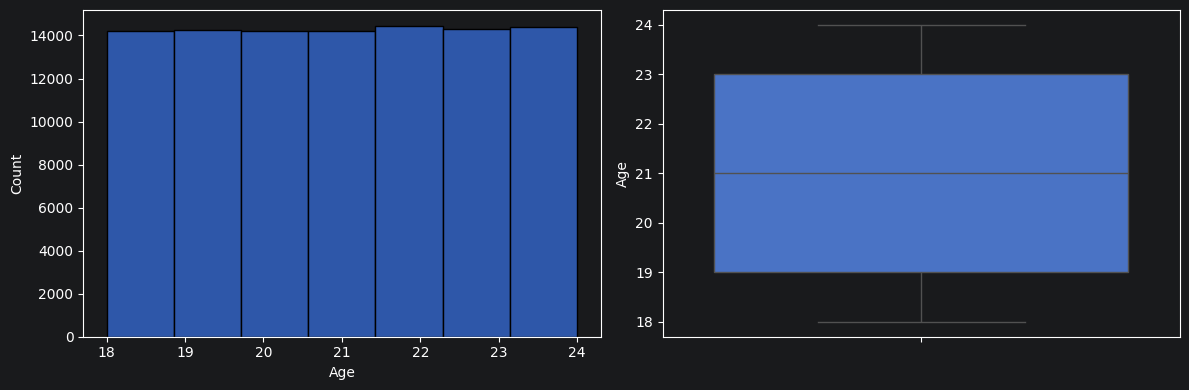

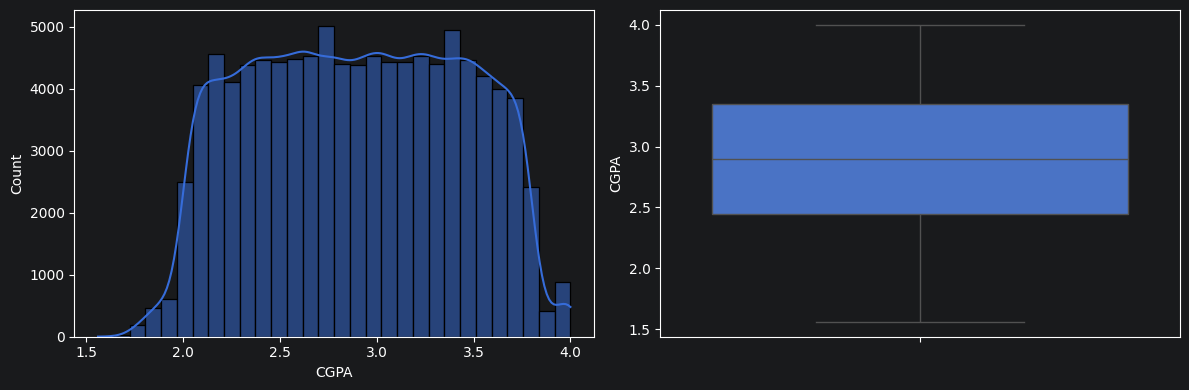

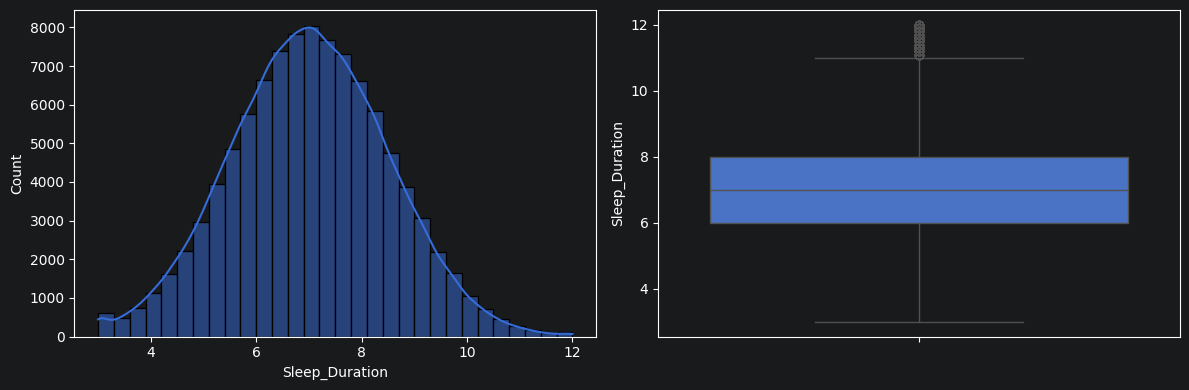

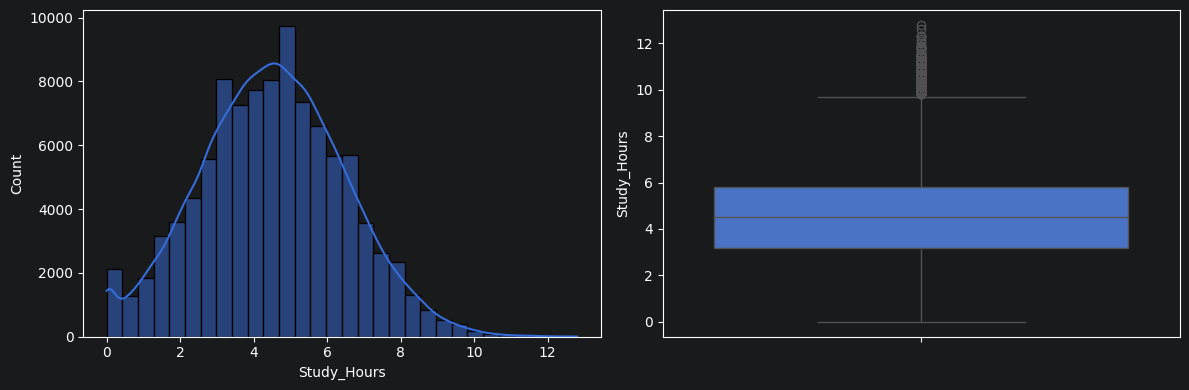

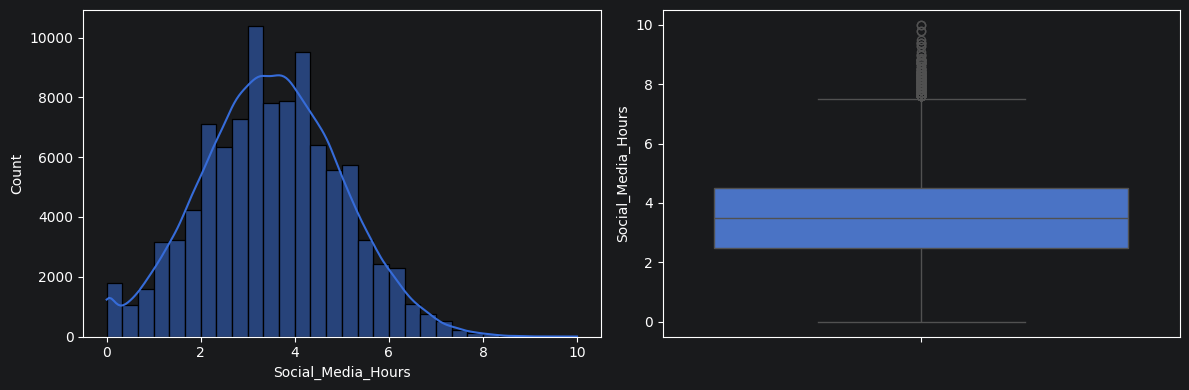

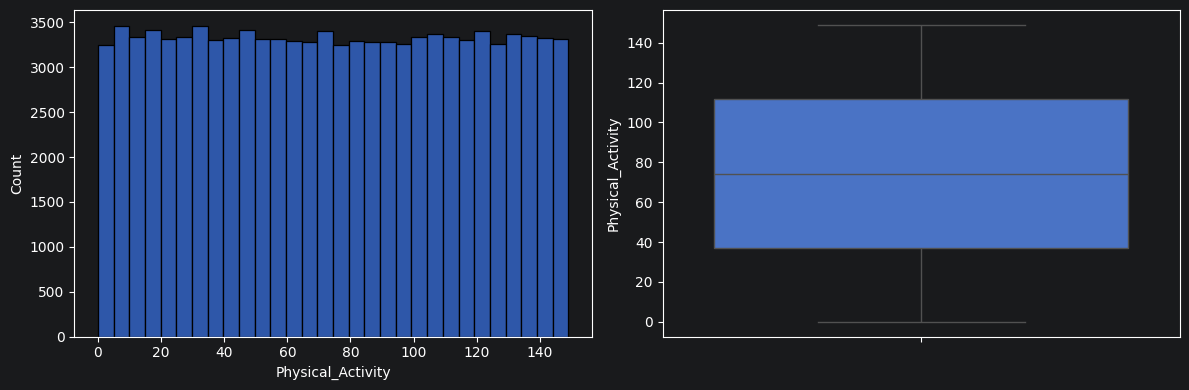

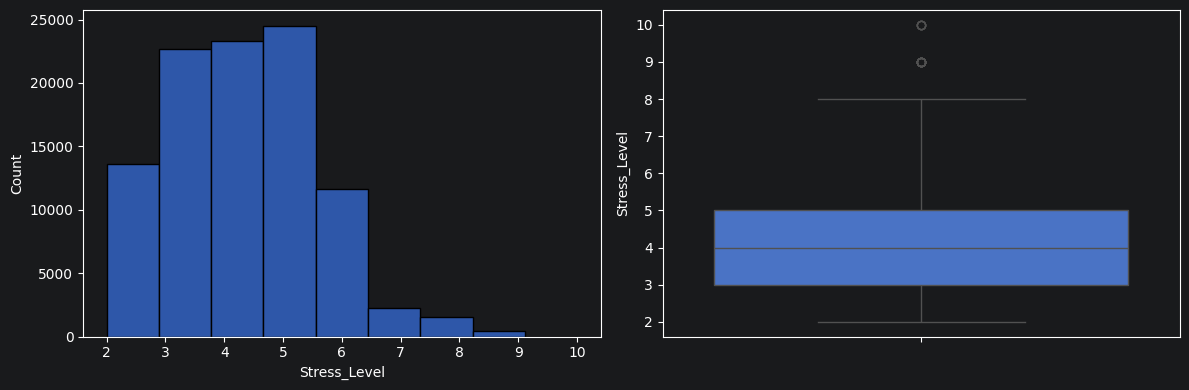

In [589]:
numeric_columns = df.select_dtypes(include=[np.number]).columns


def create_histplot_boxplot(df: pd.DataFrame, column: str):
    """
    Создает гистограмму и боксплот для колонки
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if df[column].dtype == int:
        sns.histplot(data=df, x=column, bins=min(30, df[column].unique().size), ax=axes[0])
    else:
        sns.histplot(data=df, x=column, bins=30, kde=True, ax=axes[0])
    sns.boxplot(df[column], ax=axes[1])

    plt.tight_layout()
    plt.show()


for column in numeric_columns:
    create_histplot_boxplot(df, column)


Вывод по графикам числовых столбцов:
- **Age** - распределение практически равномерное
- **CGPA** - распределение похоже на нормальное, с небольшим смещением влево
- **Sleep_Duration** - распределение похоже на нормальное. По бкосплоту видно, что существуют выбросы сверху.
- **Study_Hours** - распределение похоже на нормальное, с небольшим смещением влево. Также с выбросами сверху.
- **Social_Media_Hours** - распределение похоже на нормальное, с небольшим смещением влево. С выбросами сверху.
- **Physical_Activity_Hours** - распределение практически равномерное
- **Stress_Level** - распределение, похожее на распределение Пуассона. С выбросами в значениях 9 и 10.

Выводим также графики для категориальных столбцов

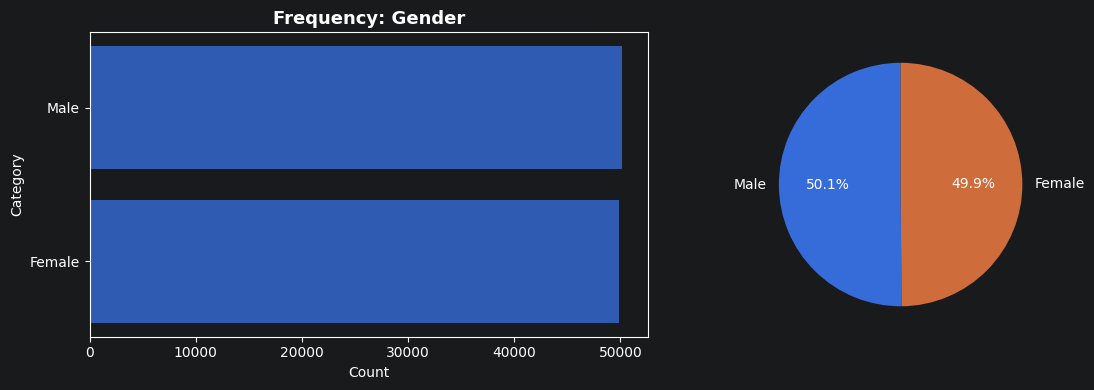

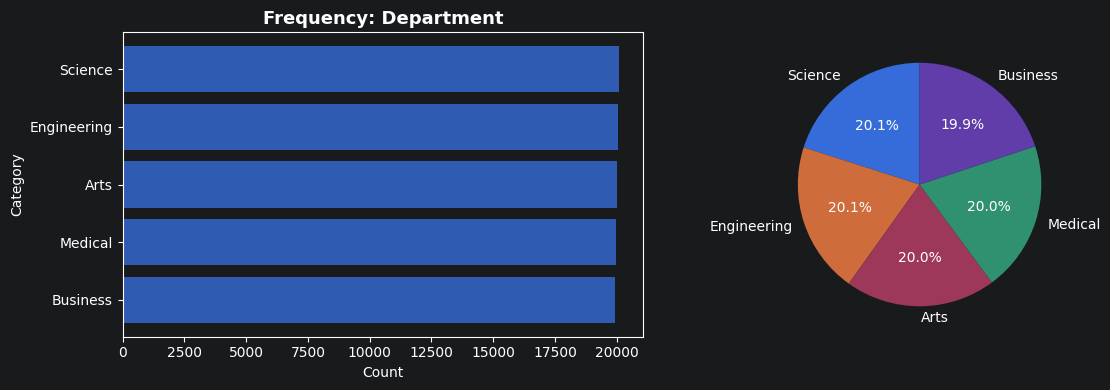

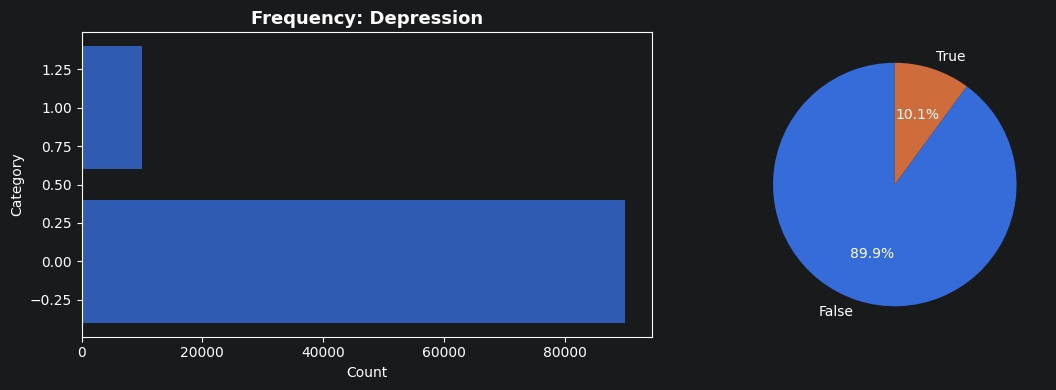

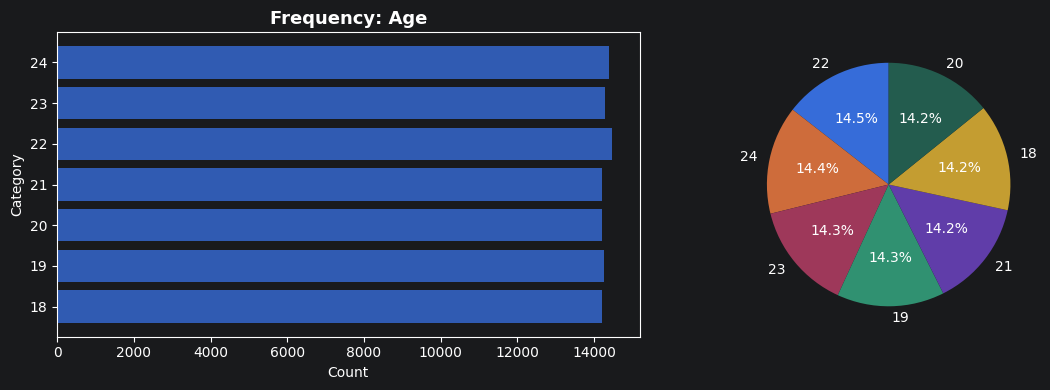

In [590]:
def create_bar_pie_charts(df: pd.DataFrame, column: str):
    """
    Создает столбчатую и круговую диаграмму для колонки
    """
    value_counts = df[column].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].barh(value_counts.index[::-1], value_counts.values[::-1], alpha=0.8)
    axes[0].set_title(f'Frequency: {column}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Category')

    axes[1].pie(
        value_counts.values,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=90,
    )
    plt.tight_layout()
    plt.show()


category_columns = df.select_dtypes(include=['str', 'category', 'object']).columns

for column in [*category_columns, 'Depression', "Age"]:
    create_bar_pie_charts(df, column)


### Предобработка данных
Удалим всех, у кого суммарное время в дне больше 24 часов (их всего 79 человек)

In [591]:
total_time = df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours']
print((total_time > 24).sum())
df = df[total_time <= 24]
print(df.info())

79
<class 'pandas.DataFrame'>
Index: 99921 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 99921 non-null  int64  
 1   Gender              99921 non-null  str    
 2   Department          99921 non-null  str    
 3   CGPA                99921 non-null  float64
 4   Sleep_Duration      99921 non-null  float64
 5   Study_Hours         99921 non-null  float64
 6   Social_Media_Hours  99921 non-null  float64
 7   Physical_Activity   99921 non-null  int64  
 8   Stress_Level        99921 non-null  int64  
 9   Depression          99921 non-null  bool   
dtypes: bool(1), float64(4), int64(3), str(2)
memory usage: 7.7 MB
None


Очистим с помощью квартилей выбросы

In [592]:
for column in numeric_columns:
    column_data = df[column]
    Q1 = column_data.quantile(0.25)
    Q3 = column_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    df = df.drop(df[mask].index)

df = df.reset_index(drop=True)

Видим по графикам, что почти все распределения идеальные, однако людей с депрессией сильно меньше, чем без неё. Поэтому можно продублировать их до равного количества, чтобы уровнять их веса при обучении логистической модели на определение депрессии.

**Важно**, что мы не будем использовать данный датасет при обучении, мы при обучении будем добавлять недостающий остаток депрессии после разделения данных, и добавлять будем только к тренировочной выборке, так как иначе у нас будет утечка данных

In [593]:
def resample_dataset(df: pd.DataFrame):
    """
    Увеличивает количество данных в датасете до равного количества людей с депрессией
    """
    df_with_depression = df[df["Depression"] == 1]
    df_without_depression = df[df["Depression"] == 0]

    df_with_depression_extended = resample(df_with_depression, replace=True, n_samples=len(df_without_depression),
                                           random_state=42)

    df_extended = pd.concat([df_with_depression_extended, df_without_depression])
    return df_extended


big_df = resample_dataset(df)
print(big_df.info())

<class 'pandas.DataFrame'>
Index: 177236 entries, 72864 to 98380
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 177236 non-null  int64  
 1   Gender              177236 non-null  str    
 2   Department          177236 non-null  str    
 3   CGPA                177236 non-null  float64
 4   Sleep_Duration      177236 non-null  float64
 5   Study_Hours         177236 non-null  float64
 6   Social_Media_Hours  177236 non-null  float64
 7   Physical_Activity   177236 non-null  int64  
 8   Stress_Level        177236 non-null  int64  
 9   Depression          177236 non-null  bool   
dtypes: bool(1), float64(4), int64(3), str(2)
memory usage: 13.7 MB
None


После уравнивания количества ещё раз просмотрим графики, чтобы убедиться, что мы не получили странных распределений.

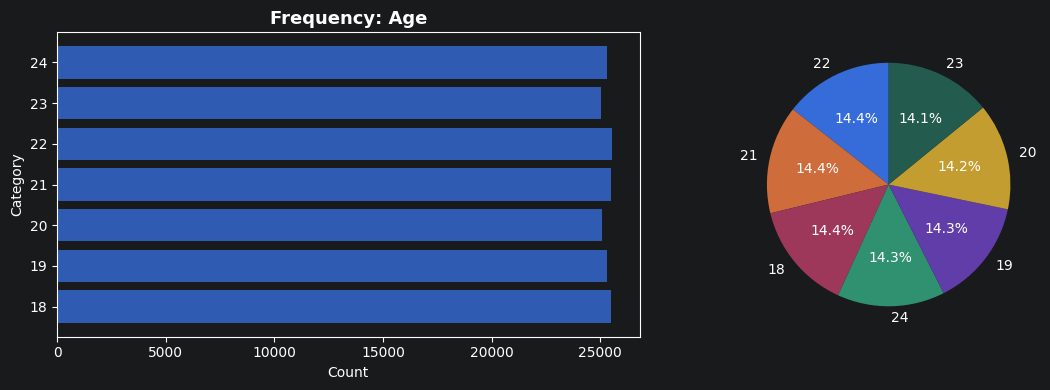

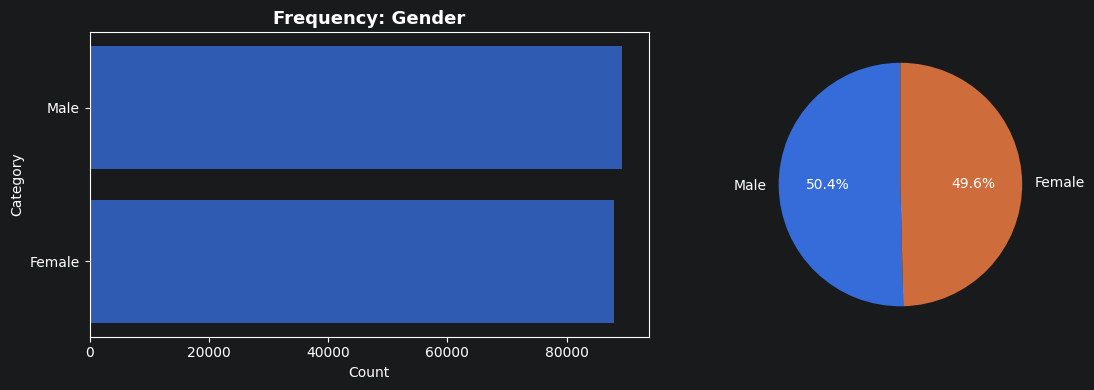

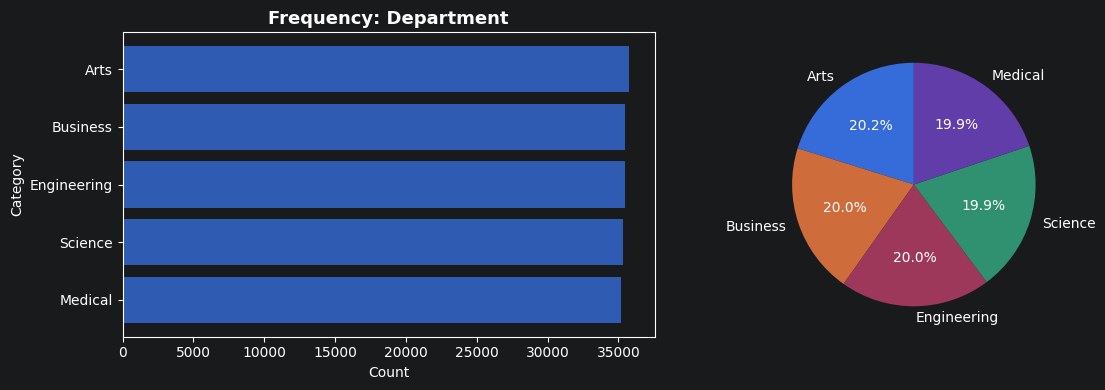

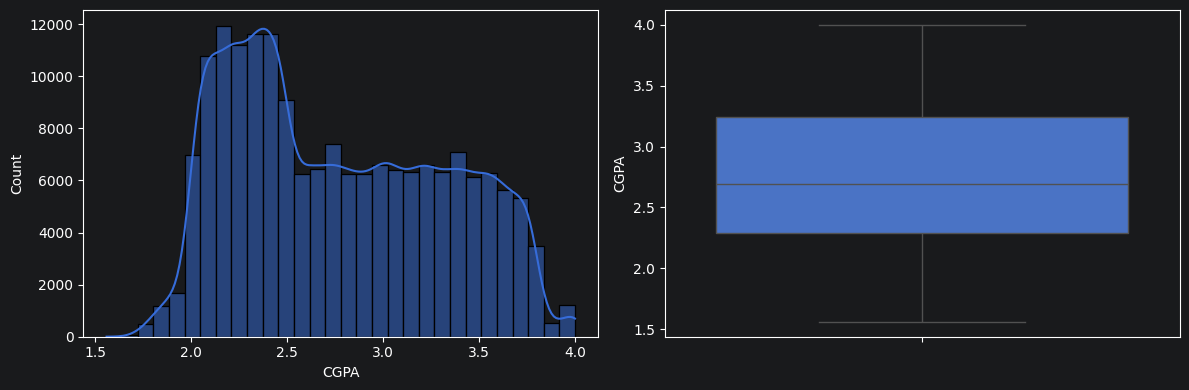

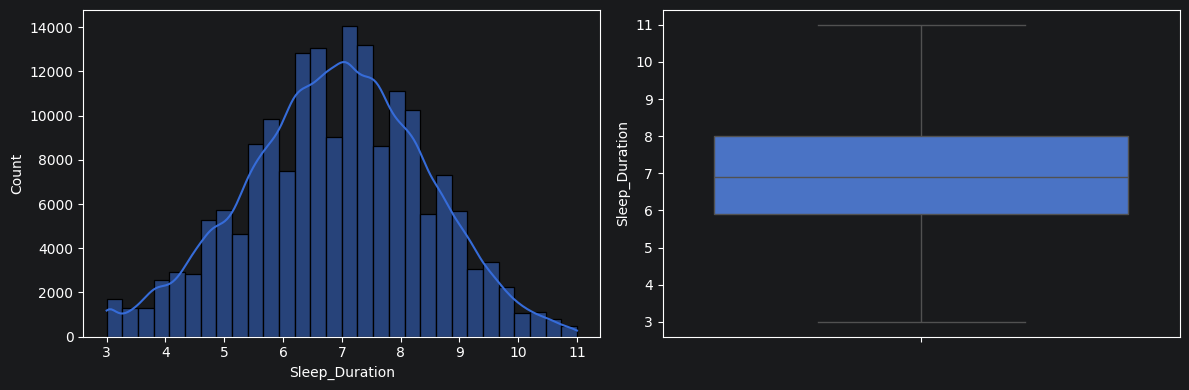

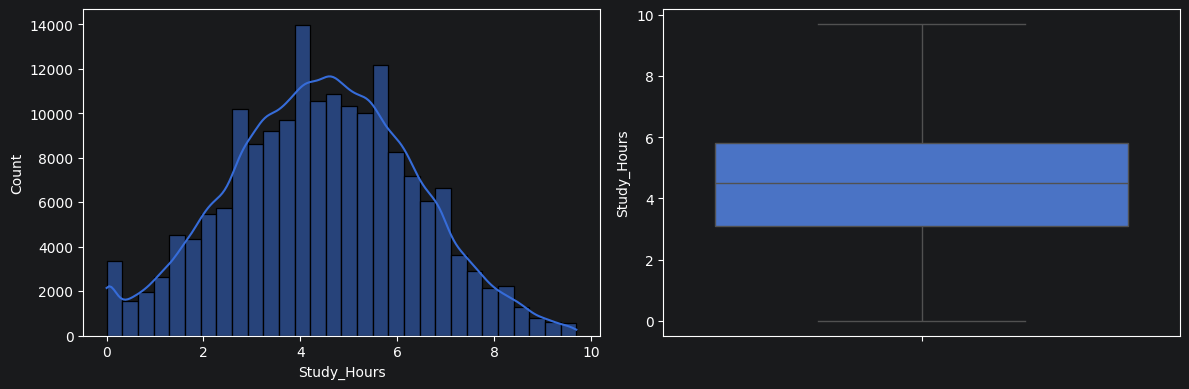

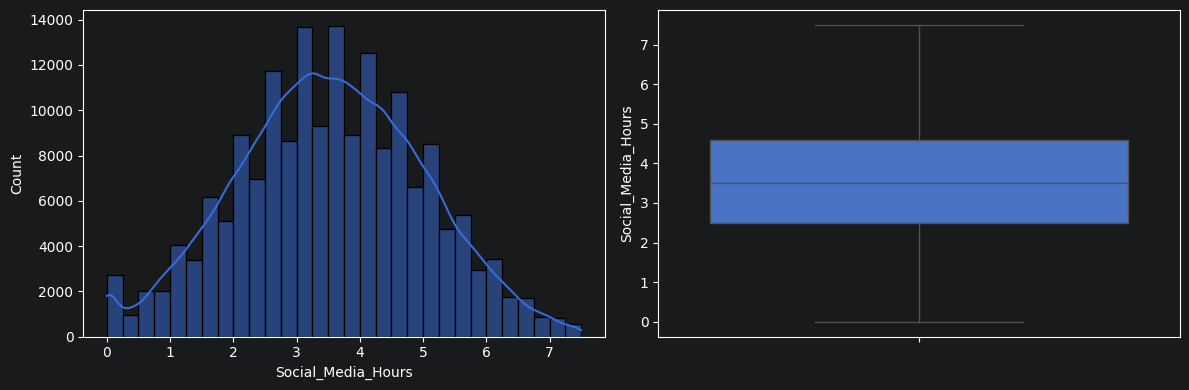

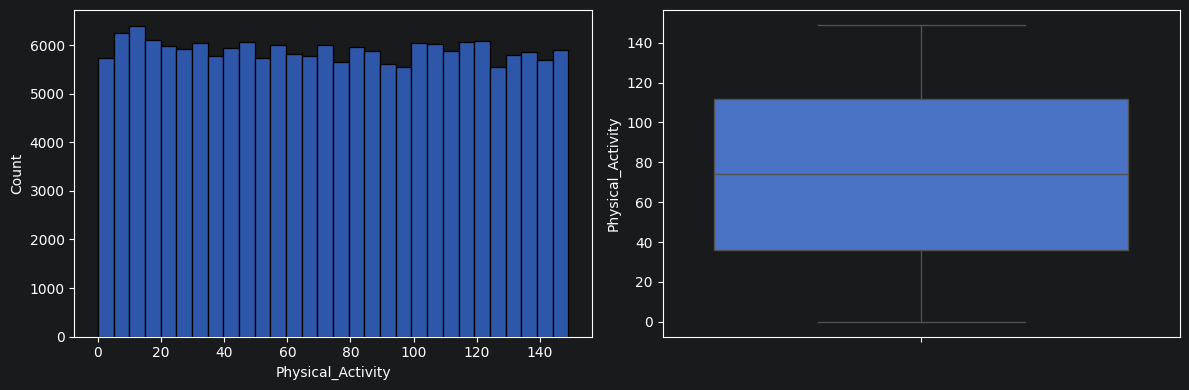

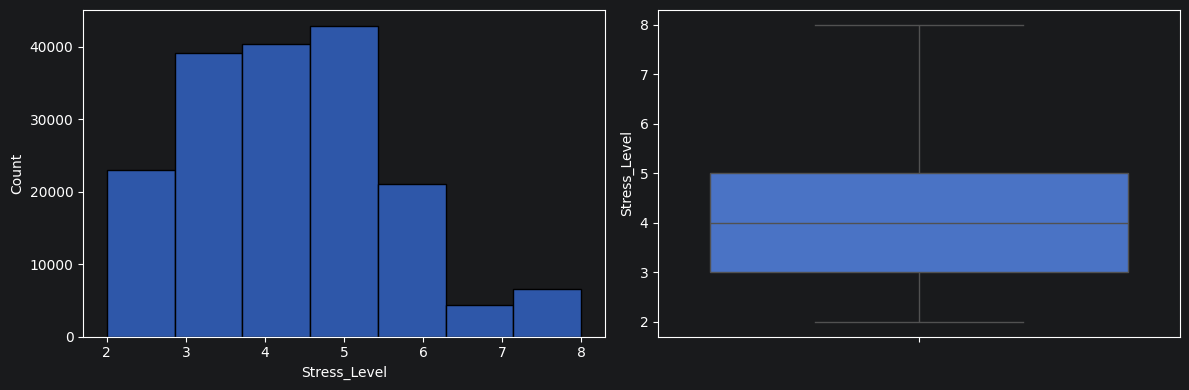

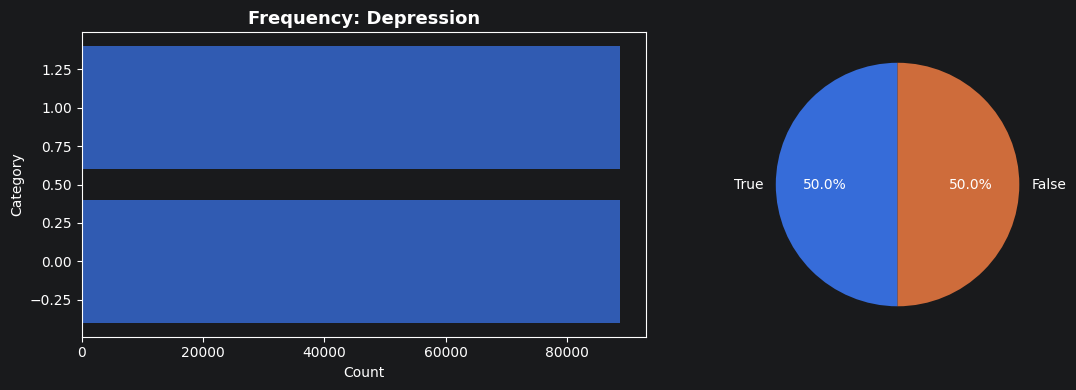

In [594]:
for column in big_df.columns:
    if (big_df[column].dtype in ['str', 'category', 'object']) or (column in ["Depression", "Age"]):
        create_bar_pie_charts(big_df, column)
    else:
        create_histplot_boxplot(big_df, column)

Видим, что существенно графики не изменилось. Однако поменялась структура графика средней оценки, это может значить, что люди с депрессией чаще имеют более низкую среднюю оценку, чем люди без депрессии.

Построим теперь график корреляции для числовых признаков, чтобы понять, какие признаки сильно между собой коррелирует и стоит ли какие-то из них не учитывать при построении модели.

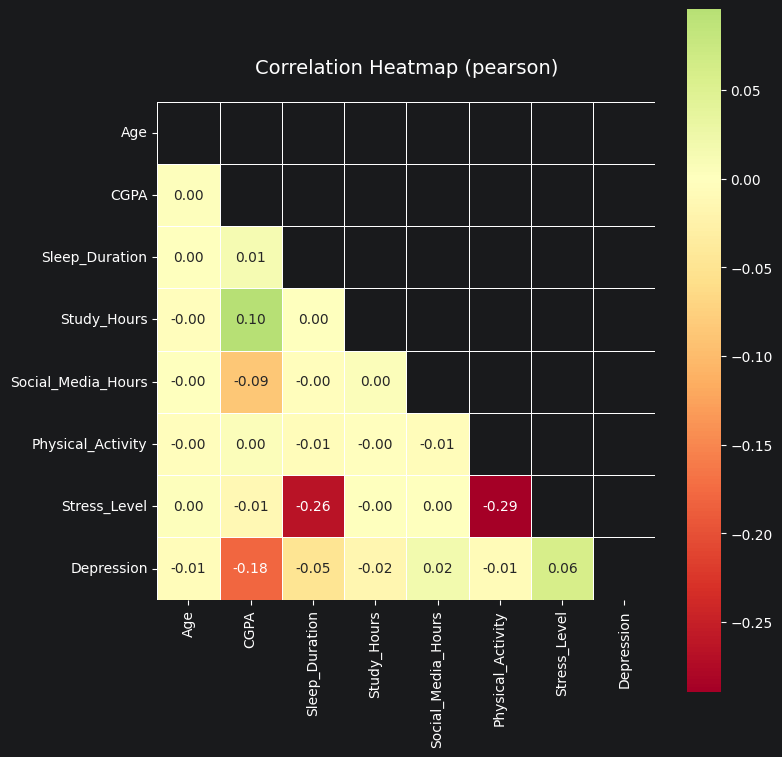

In [595]:
def plot_correlation_heatmap(df, method='pearson', threshold=0.7):
    numeric = df.select_dtypes(include=[np.number, 'bool'])
    corr = numeric.corr(method=method)

    plt.figure(figsize=(8, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True, linewidths=0.5)
    plt.title(f'Correlation Heatmap ({method})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()


plot_correlation_heatmap(df, method='pearson')

Видим, что между собой признаки особо не коррелирует, также они слабо коррелируют относительно депрессии и средней оценки.

### Feature engineering
Создадим два датасета, один из них обогатим новыми признаками, а в другой почистим от нерелевантных

In [596]:
dataset1 = df.copy()
dataset1["Recovery"] = df["Sleep_Duration"] * df["Physical_Activity"] / (df['Study_Hours'] + 0.1)
dataset1["Hard_Job"] = df["Study_Hours"] * df["Physical_Activity"]
dataset1["Stress"] = df["Stress_Level"] * df["Social_Media_Hours"] * df["Study_Hours"]
dataset1.info()

dataset2 = df.copy()
dataset2 = dataset2.drop(columns=["Department", "Gender", "Age"])
dataset2.info()

<class 'pandas.DataFrame'>
RangeIndex: 98381 entries, 0 to 98380
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 98381 non-null  int64  
 1   Gender              98381 non-null  str    
 2   Department          98381 non-null  str    
 3   CGPA                98381 non-null  float64
 4   Sleep_Duration      98381 non-null  float64
 5   Study_Hours         98381 non-null  float64
 6   Social_Media_Hours  98381 non-null  float64
 7   Physical_Activity   98381 non-null  int64  
 8   Stress_Level        98381 non-null  int64  
 9   Depression          98381 non-null  bool   
 10  Recovery            98381 non-null  float64
 11  Hard_Job            98381 non-null  float64
 12  Stress              98381 non-null  float64
dtypes: bool(1), float64(7), int64(3), str(2)
memory usage: 9.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 98381 entries, 0 to 98380
Data columns (total 7 columns):
 # 

Во втором датасете выбросили колонки Age, Gender и Departament, так как они не зависят от образа жизни человека и хоть и могут иметь небольшое влияние на наличие у него депрессии, это влияние не существенно

### Разделение данных
Напишем простенькую функцию, которая будет разделять данные на тренировочку, валидационную и тестовую выборку а также применение к ней StandardScaler-a так он лучше подходит для приблизительно нормально распределенных данных, а также хорошо совместим с линейными моделями.

Также закодируем категориальные признаки с помощью one-hot encoder-a, то есть каждому уникальному признаку будет соответствовать новая bool колонка.


In [597]:
def split_dataset(dataset, target_column: str, need_resample: bool = False):
    """
    Разделяет датасет на тренировочку, валидационную и тестовую выборку
    """
    y = dataset[target_column]
    X = dataset.drop(columns=[target_column])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        shuffle=True
    )

    X_test, X_validate, y_test, y_validate = train_test_split(
        X_test, y_test,
        test_size=0.5,
        random_state=42,
        shuffle=True
    )

    if need_resample:
        balanced = resample_dataset(pd.concat([X_train, y_train], axis=1))

        X_train = balanced.drop(columns=[target_column])
        y_train = balanced[target_column]

    num_columns = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cat_columns = X_train.select_dtypes(include=["object", "category", "str"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_columns),
            ("cat", OneHotEncoder(handle_unknown='ignore', drop='first'), cat_columns),
        ])

    X_train_scaled = preprocessor.fit_transform(X_train)
    X_validate_scaled = preprocessor.transform(X_validate)
    X_test_scaled = preprocessor.transform(X_test)

    features = preprocessor.get_feature_names_out()

    return X_train_scaled, X_validate_scaled, X_test_scaled, y_train, y_validate, y_test, features


### Обучение модели для задачи регрессии
Обучим модель линейной регрессии LinearRegression, а также выведем её метрики, такие как: MAE, RMSE, R^2, MAPE. Также выведем веса модели в виде столбчатой диаграммы, кривую распределяемости и метрики на разных данных.

In [598]:
def create_coef_bar(model: LogisticRegression | LinearRegression, dataset: pd.DataFrame | pd.Series):
    """
    Создает график важности признаков
    """
    columns = dataset
    coefs = model.coef_
    if coefs.ndim == 2:
        coefs = coefs[0]

    plt.figure(figsize=(16, 9))
    colors = ['green' if w > 0 else 'red' for w in coefs]
    plt.barh(columns, coefs, color=colors)
    plt.axvline(x=0, color='black', linestyle='--')
    plt.title('Важность признаков')
    plt.tight_layout()
    plt.show()


def create_learning_curve(model, X, y, score):
    """
    Создает кривую обучаемости
    """
    train_sizes = np.linspace(0.1, 1.0, 10)

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring=score, n_jobs=-1,
        train_sizes=train_sizes, random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(16, 9))
    plt.plot(train_sizes, train_mean, 'o-', color="#e74c3c", label="Training score")

    plt.plot(train_sizes, test_mean, 'o-', color="#2ecc71", label="Cross-validation score")

    plt.title(f"Кривая обучаемости")
    plt.xlabel("Количество данных для обучения")
    plt.ylabel(score)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


def create_histplot_of_leftover(y_test, y_test_predict, center=0.0):
    """
    Создает график распределения остатков
    """
    residuals = y_test - y_test_predict
    plt.figure(figsize=(16, 9))
    sns.histplot(residuals, bins=50, kde=True)
    plt.axvline(x=center, color='red', linestyle='--', lw=2)
    plt.xlabel('Значение остатка')
    plt.ylabel('Частота')
    plt.title('Распределение остатков')
    plt.tight_layout()
    plt.show()


def create_comparison_of_metrics(train_metrics, test_metrics, metrics_names):
    """
    Создает график сравнения метрик по train и test
    """
    # metrics_names = ['R²', 'MAE', 'RMSE']
    x_pos = np.arange(len(metrics_names))
    width = 0.35

    train_vals = [train_metrics[name] for name in metrics_names]
    test_vals = [test_metrics[name] for name in metrics_names]

    plt.figure(figsize=(16, 9))
    plt.bar(x_pos - width / 2, train_vals, width, label='Train')
    plt.bar(x_pos + width / 2, test_vals, width, label='Test')
    plt.xticks(x_pos, metrics_names)
    plt.ylabel('Значение')
    plt.title('Сравнение метрик: Train vs Test')
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_regression(y_true, y_pred, dataset_name="Dataset", need_print=True):
    """
    Выводит MAE, RMSE, R^2, MAPE метрики для обученной модели
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    if need_print:
        print(f"Метрики для {dataset_name}:")
        print(f"  MAE:  {mae:,.2f}")
        print(f"  RMSE: {rmse:,.2f}")
        print(f"  R2:   {r2:.4f}")
        print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

Создадим функцию, которая будет по валидационным данным подбирать метрики шага и количества эпох для модели классификации и регрессии. В основе будут лежать линейные модели на основе стохастического градиентного спуска

In [599]:
def find_best(X_train, X_validate, y_train, y_validate, which: str = "classification"):
    n_epochs = [20, 50, 100, 200]
    rates = [1e-4, 5e-4, 1e-3, 5e-3]

    results = []

    for learning_rate in rates:
        for n_epoch in n_epochs:
            if which == "classification":
                model = SGDClassifier(loss="log_loss", learning_rate="constant", penalty="l1",
                                      eta0=learning_rate, max_iter=n_epoch, random_state=42, tol=None)
                model.fit(X_train, y_train)

                val_pred = model.predict(X_validate)
                val_proba = model.predict_proba(X_validate)[:, 1]

                row = evaluate_classification(y_validate, val_pred, val_proba, need_print=False)
            else:
                model = SGDRegressor(loss="squared_error", learning_rate="constant", max_iter=n_epoch,
                                     eta0=learning_rate, random_state=42, tol=None)
                model.fit(X_train, y_train)
                predict = model.predict(X_validate)

                row = evaluate_regression(y_validate, predict, need_print=False)

            row['learning_rate'] = learning_rate
            row['n_epochs'] = n_epoch

            results.append(row)
    if which == "classification":
        results_df = pd.DataFrame(results).sort_values(["F1", "AUC-ROC"], ascending=False)
        n_epoch = int(results_df.iloc[0]['n_epochs'])
        rate = float(results_df.iloc[0]['learning_rate'])
        model = SGDClassifier(loss="log_loss", learning_rate="constant", penalty="l1",
                              eta0=rate, max_iter=n_epoch, random_state=42, tol=None)
    else:
        results_df = pd.DataFrame(results).sort_values(["R2", "RMSE"], ascending=[False, True])
        n_epoch = int(results_df.iloc[0]['n_epochs'])
        rate = float(results_df.iloc[0]['learning_rate'])
        model = SGDRegressor(loss="squared_error", learning_rate="constant", max_iter=n_epoch,
                             eta0=rate, random_state=42, tol=None)
    model.fit(X_train, y_train)
    return results_df, model

Обучим модель на первом датасете

Расширенный датасет:
Метрики для Train:
  MAE:  0.44
  RMSE: 0.52
  R2:   0.0510
  MAPE: 16.08%
Метрики для Validate:
  MAE:  0.45
  RMSE: 0.52
  R2:   0.0433
  MAPE: 16.22%
Метрики для Test:
  MAE:  0.44
  RMSE: 0.52
  R2:   0.0451
  MAPE: 16.14%


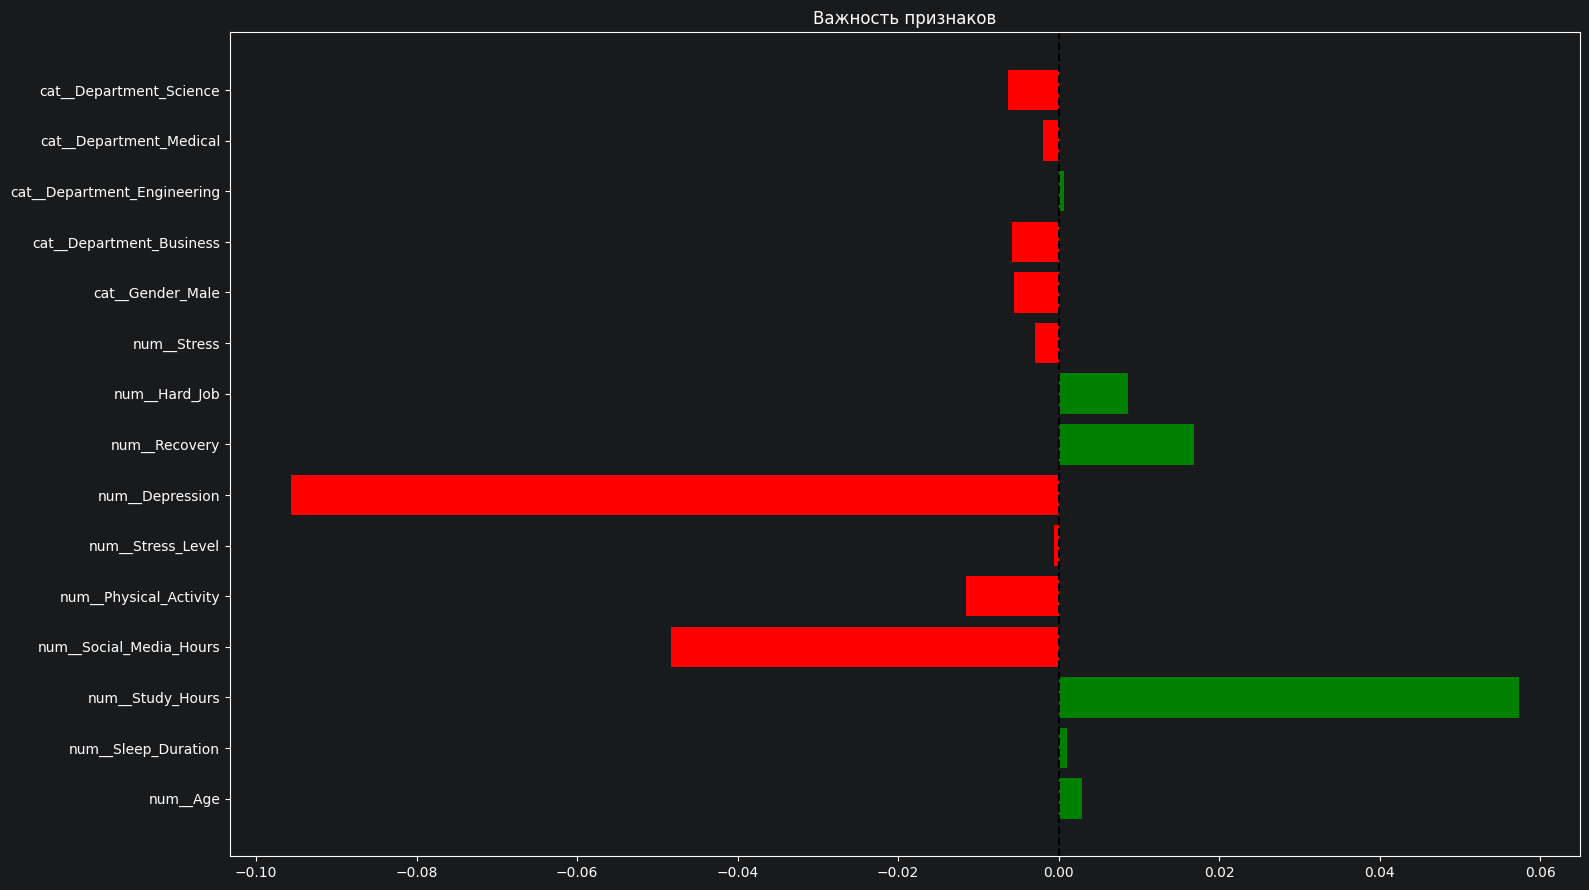

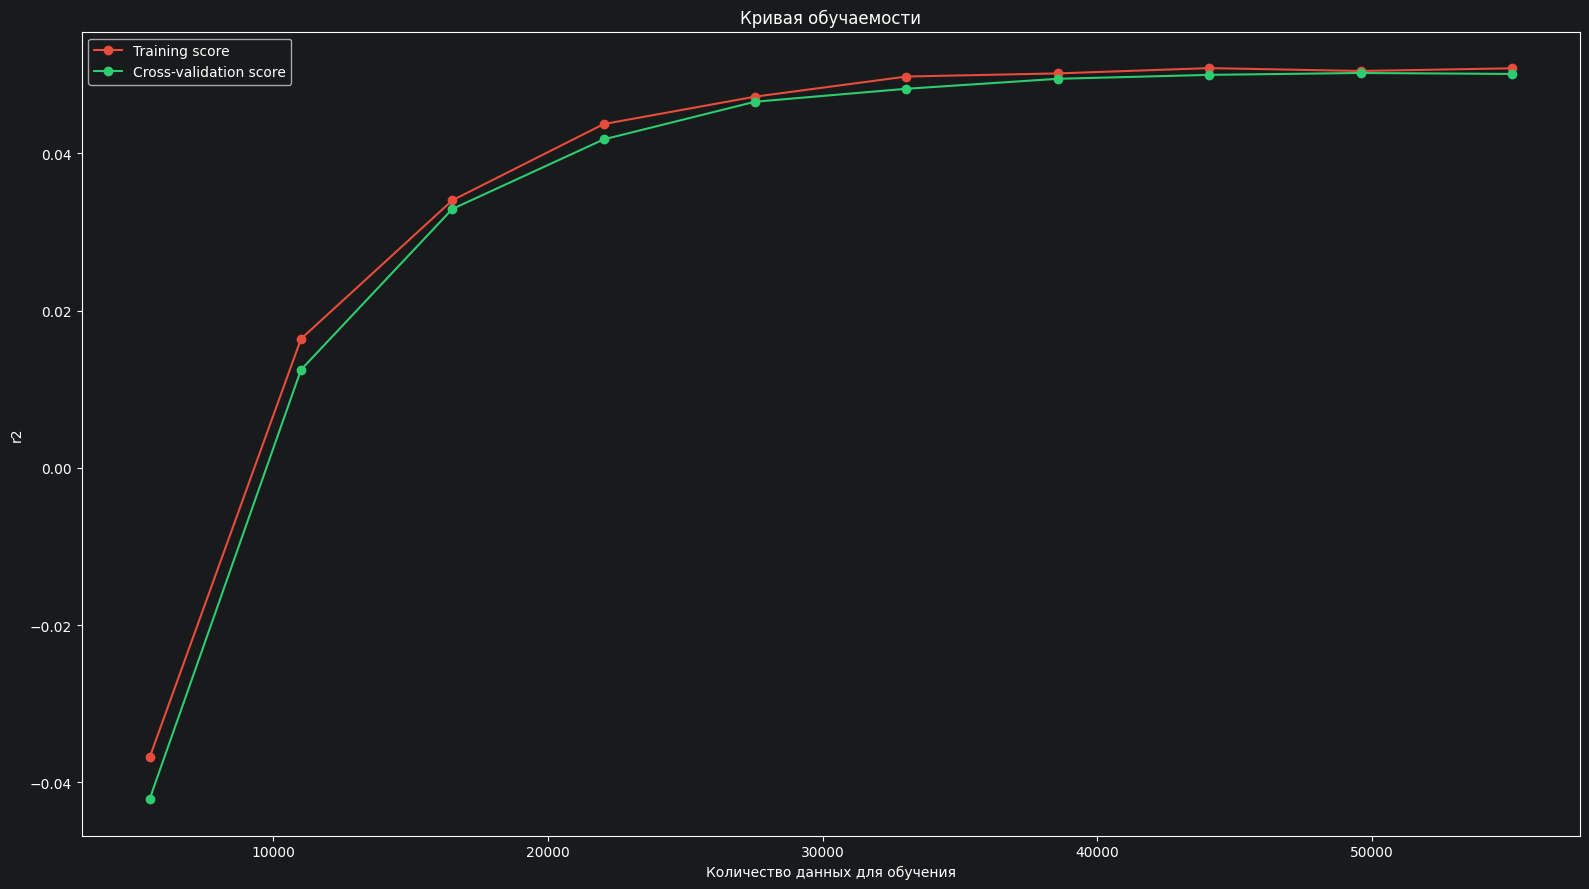

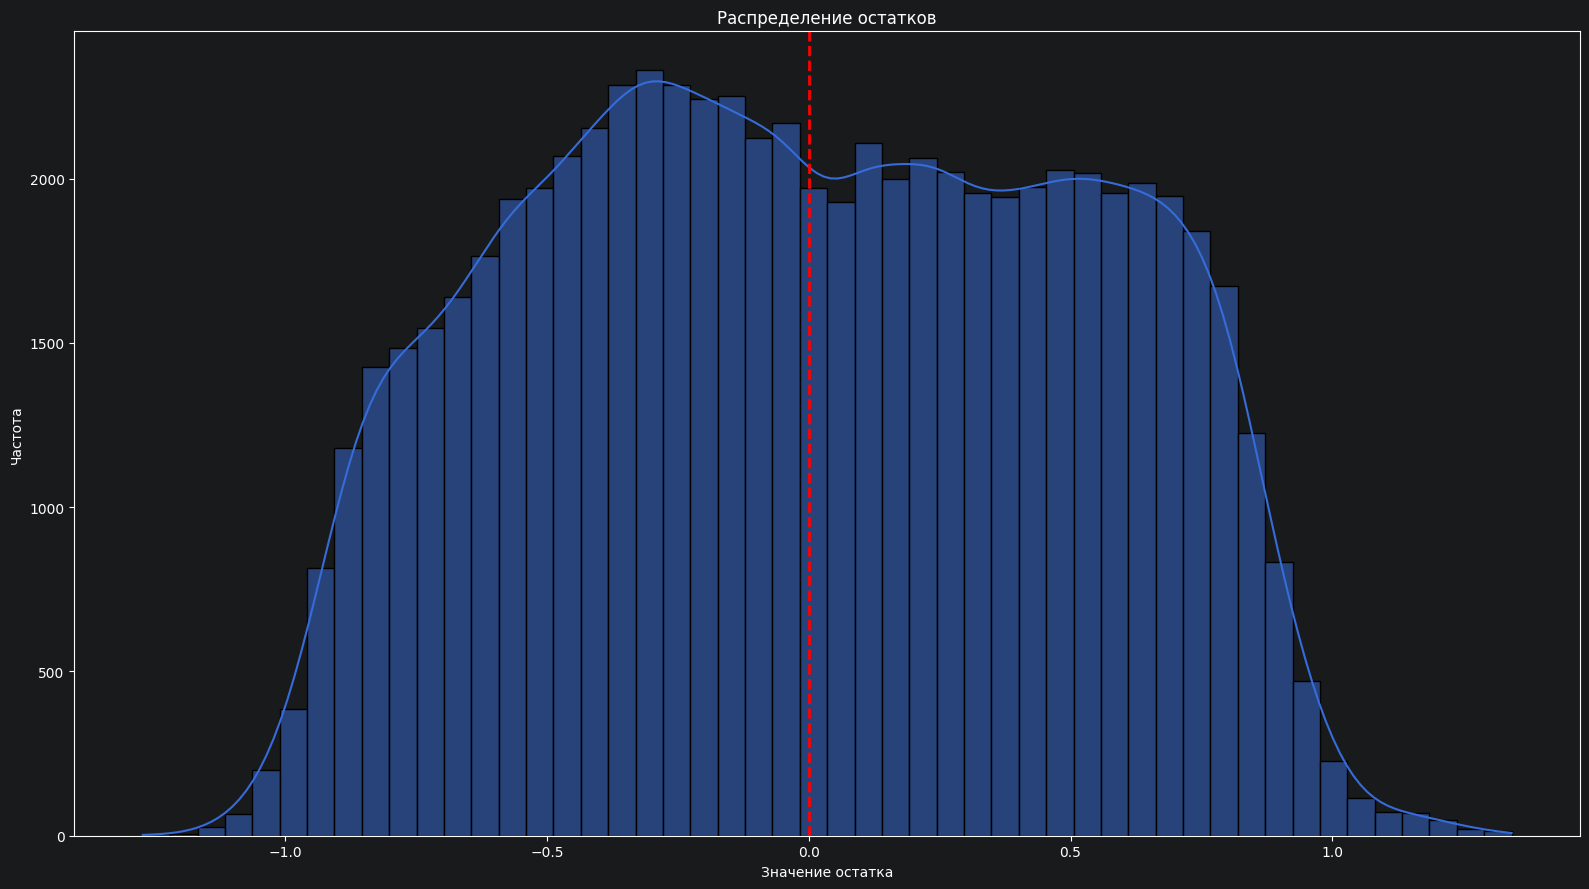

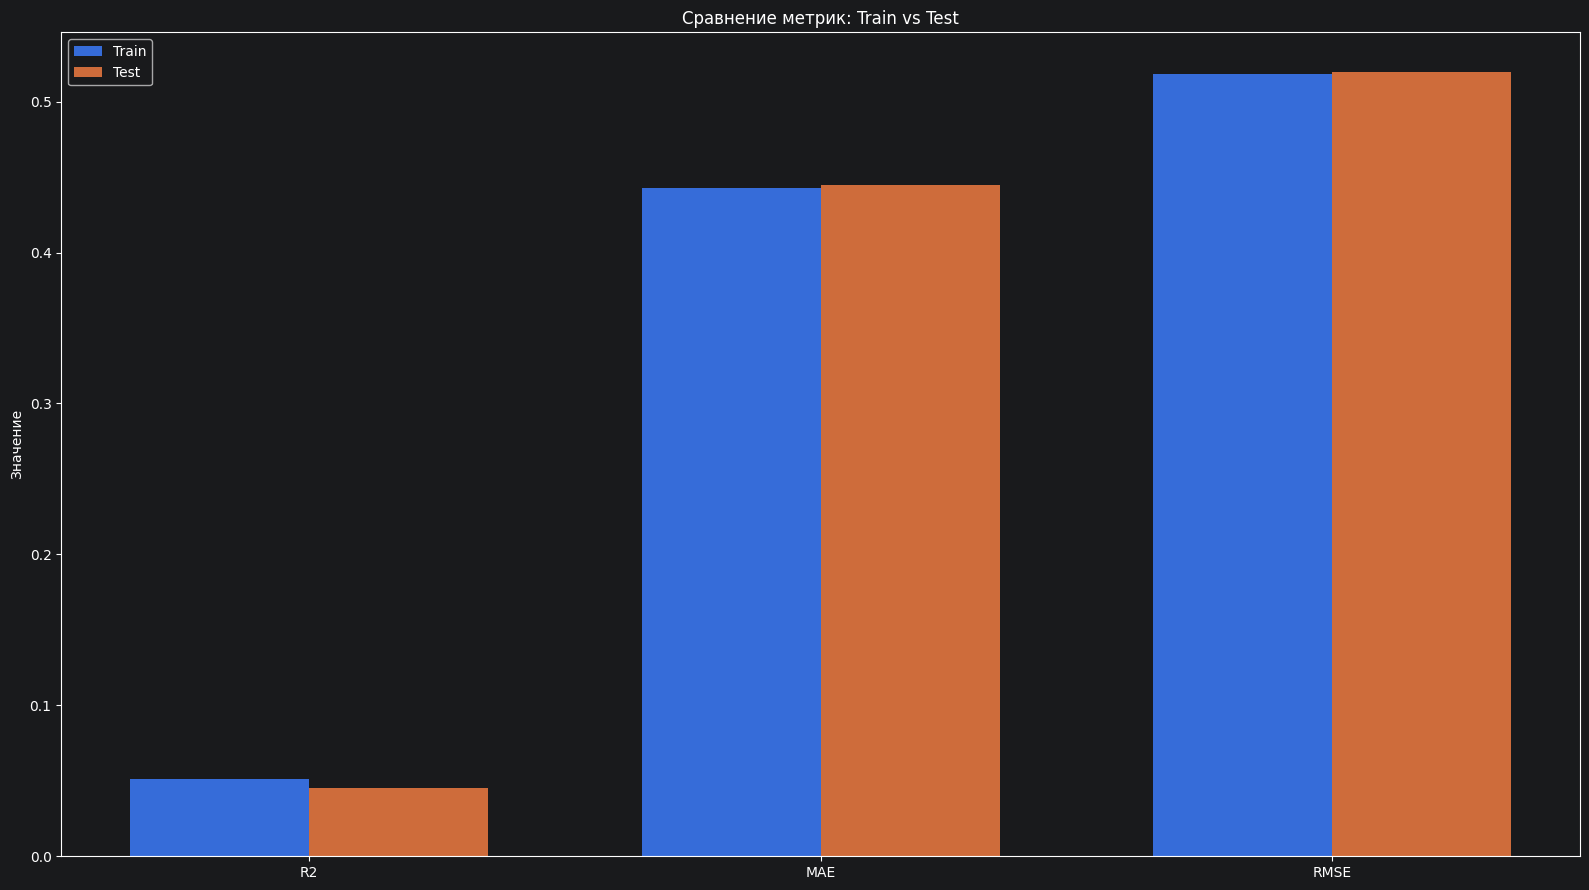

In [600]:
print("Расширенный датасет:")
X_train, X_validate, X_test, y_train, y_validate, y_test, features = split_dataset(dataset1, "CGPA")
# print(features)
results, model_1 = find_best(X_train, X_validate, y_train, y_validate, "regression")

y_train_predict = model_1.predict(X_train)
y_validate_predict = model_1.predict(X_validate)
y_test_predict = model_1.predict(X_test)

train_metrics = evaluate_regression(y_train, y_train_predict, dataset_name="Train")
validate_metrics = evaluate_regression(y_validate, y_validate_predict, dataset_name="Validate")
test_metrics = evaluate_regression(y_test, y_test_predict, dataset_name="Test")

create_coef_bar(model_1, features)
create_learning_curve(model_1, X_train, y_train, "r2")
create_histplot_of_leftover(y_train, y_train_predict)
metrics_names = ['R2', 'MAE', 'RMSE']
create_comparison_of_metrics(train_metrics, test_metrics, metrics_names)

Обучим модель на втором датасете

Уменьшенный датасет:
Метрики для Train:
  MAE:  0.44
  RMSE: 0.52
  R2:   0.0501
  MAPE: 16.08%
Метрики для Test:
  MAE:  0.44
  RMSE: 0.52
  R2:   0.0444
  MAPE: 16.14%


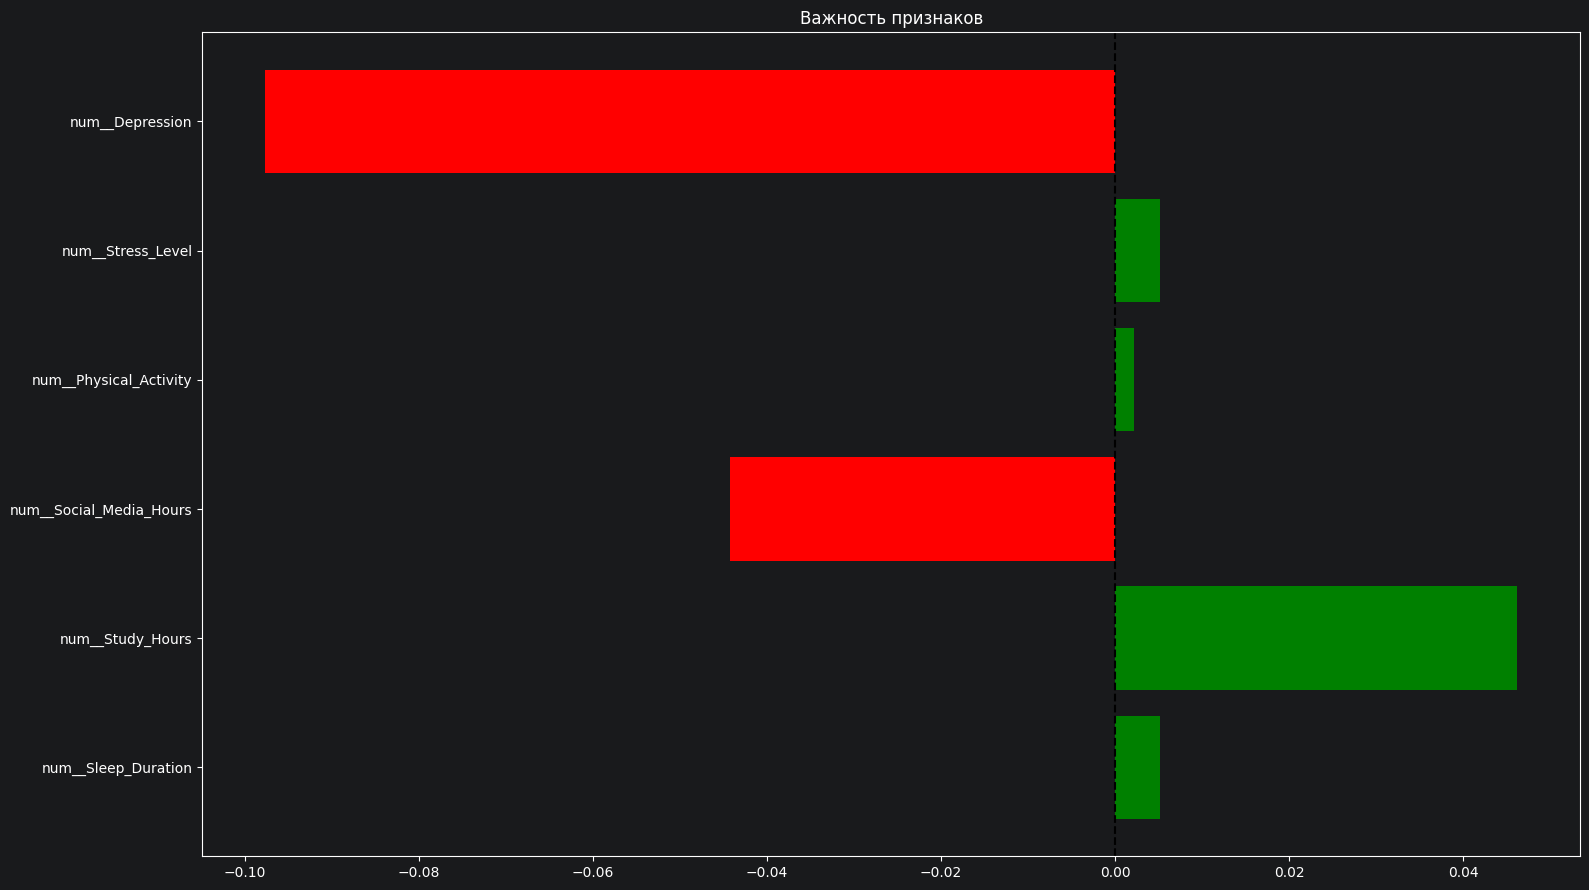

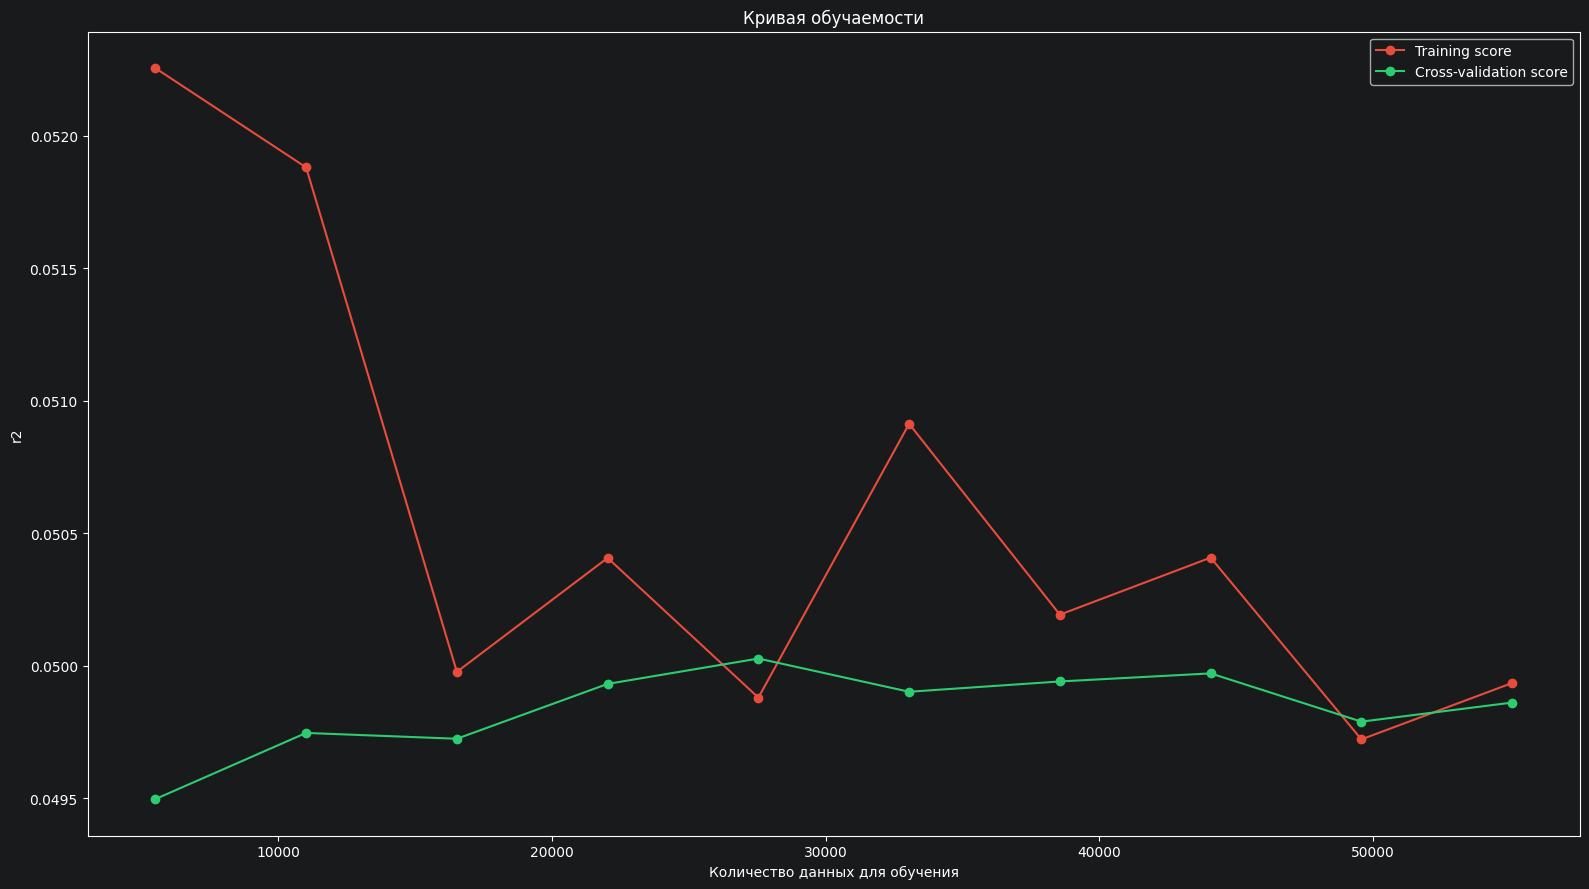

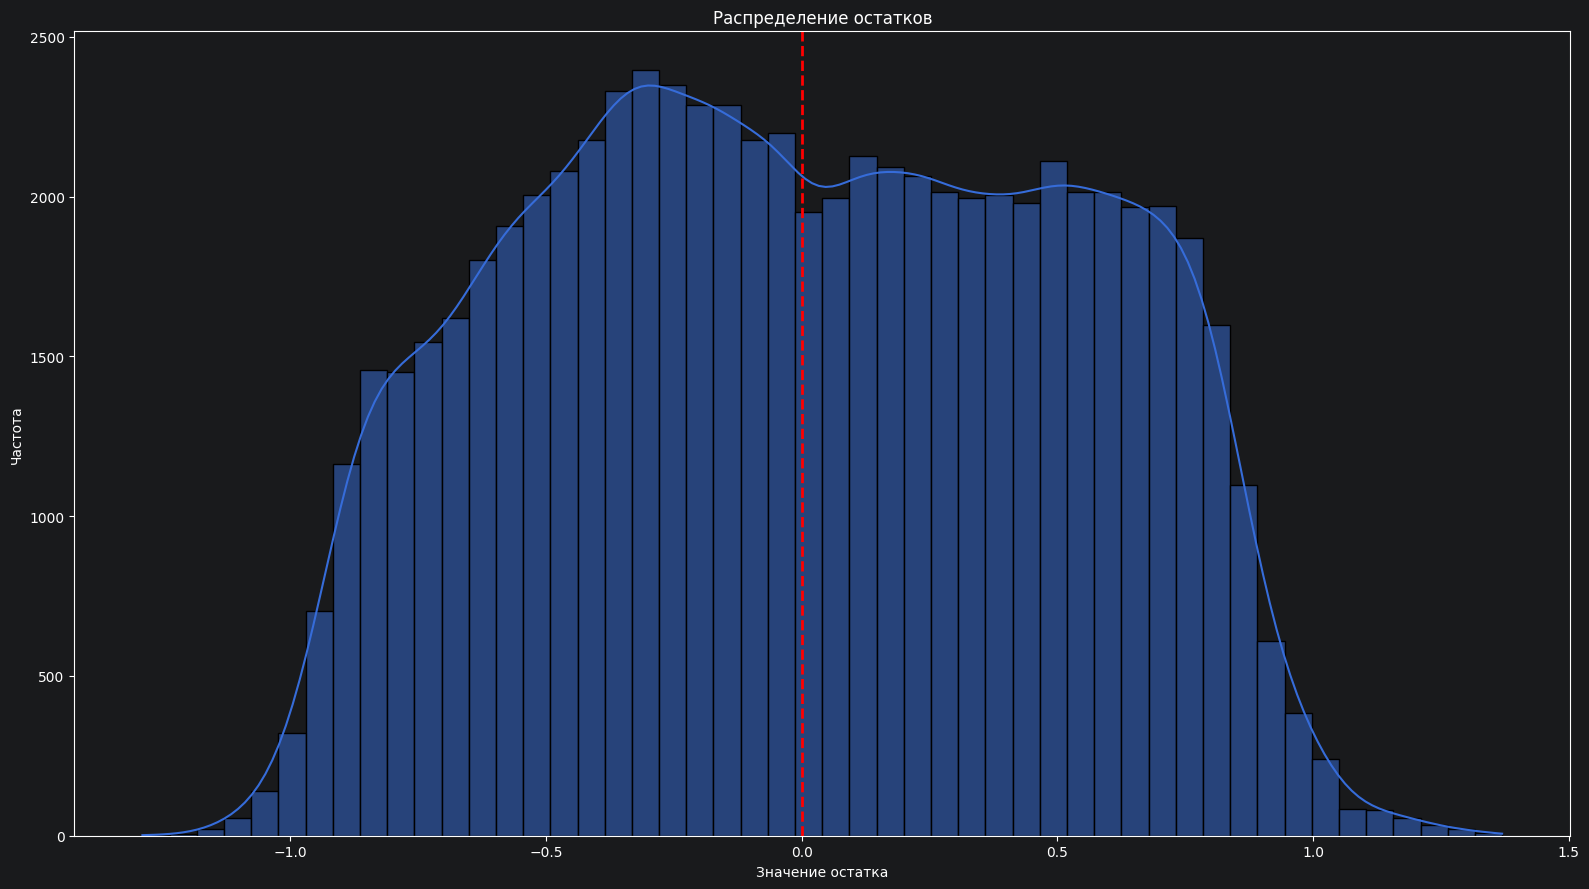

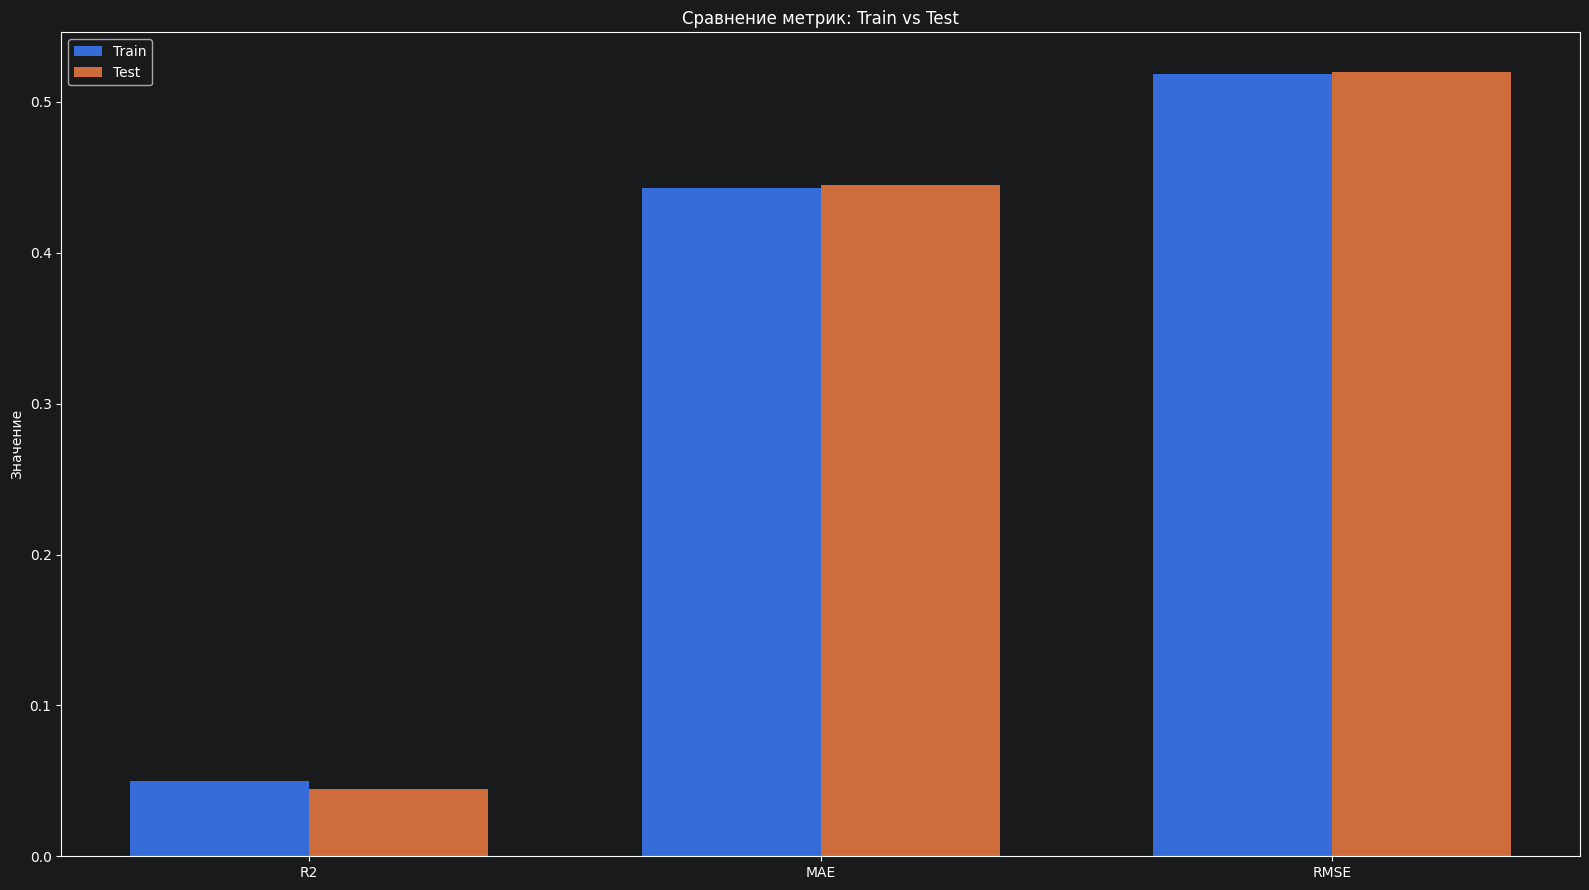

In [601]:
print("Уменьшенный датасет:")
X_train, X_validate, X_test, y_train, y_validate, y_test, features = split_dataset(dataset2, "CGPA")
# print(features)
results, model_2 = find_best(X_train, X_validate, y_train, y_validate, "regression")
model_2.fit(X_train, y_train)

y_train_predict = model_2.predict(X_train)
y_test_predict = model_2.predict(X_test)

train_metrics = evaluate_regression(y_train, y_train_predict, dataset_name="Train")
test_metrics = evaluate_regression(y_test, y_test_predict, dataset_name="Test")

create_coef_bar(model_2, features)
create_learning_curve(model_2, X_train, y_train, score='r2')
create_histplot_of_leftover(y_train, y_train_predict)
create_comparison_of_metrics(train_metrics, test_metrics, metrics_names)

По графикам видим, что модель не переобучена, так как метрики на тестовой выборке почти совпадают с метриками на обучающей выборке

### Обучение модели для задачи классификации
Обучим модель логистической регрессии LogisticRegression, а также выведем её метрики, такие как: Accuracy, Precision, Recall, F1-Score, AUC-ROC. Также выведем веса модели в виде столбчатой диаграммы.

In [602]:
def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Dataset", need_print: bool = True):
    """
    Выводит Accuracy, Precision, Recall, F1-Score, AUC-ROC метрики
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    auc_roc = None
    if y_proba is not None:
        auc_roc = roc_auc_score(y_true, y_proba)

    if need_print:
        print(f"Метрики для {dataset_name}:")
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        if auc_roc:
            print(f"  AUC-ROC:   {auc_roc:.4f}")
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}


def create_roc_curve(y_test, y_test_proba, test_metrics):
    plt.figure(figsize=(16, 9))
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_metrics["AUC-ROC"]:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Test)')
    plt.tight_layout()
    plt.show()


def create_confusion_matrix(y_test, y_test_predict):
    plt.figure(figsize=(16, 9))
    cm = confusion_matrix(y_test, y_test_predict)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['0 (Низкая)', '1 (Высокая)'],
                yticklabels=['0 (Низкая)', '1 (Высокая)'])
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Фактический класс')
    plt.title('Confusion Matrix (Test)')
    plt.tight_layout()
    plt.show()


По validate подберем подходящие параметры по количеству эпох и шагу для линейной модели классификации на основе стохастического градиентного спуска (SGDClassifier), чтобы попытаться максимизировать метрики на тестовом датасете.

Обучим модель на первом датасете.


Метрики для Train:
  Accuracy:  0.6496
  Precision: 0.6426
  Recall:    0.6742
  F1-Score:  0.6580
  AUC-ROC:   0.6841
Метрики для Validate:
  Accuracy:  0.6270
  Precision: 0.1613
  Recall:    0.6596
  F1-Score:  0.2592
  AUC-ROC:   0.6726
Метрики для Test:
  Accuracy:  0.6334
  Precision: 0.1695
  Recall:    0.6662
  F1-Score:  0.2703
  AUC-ROC:   0.6764


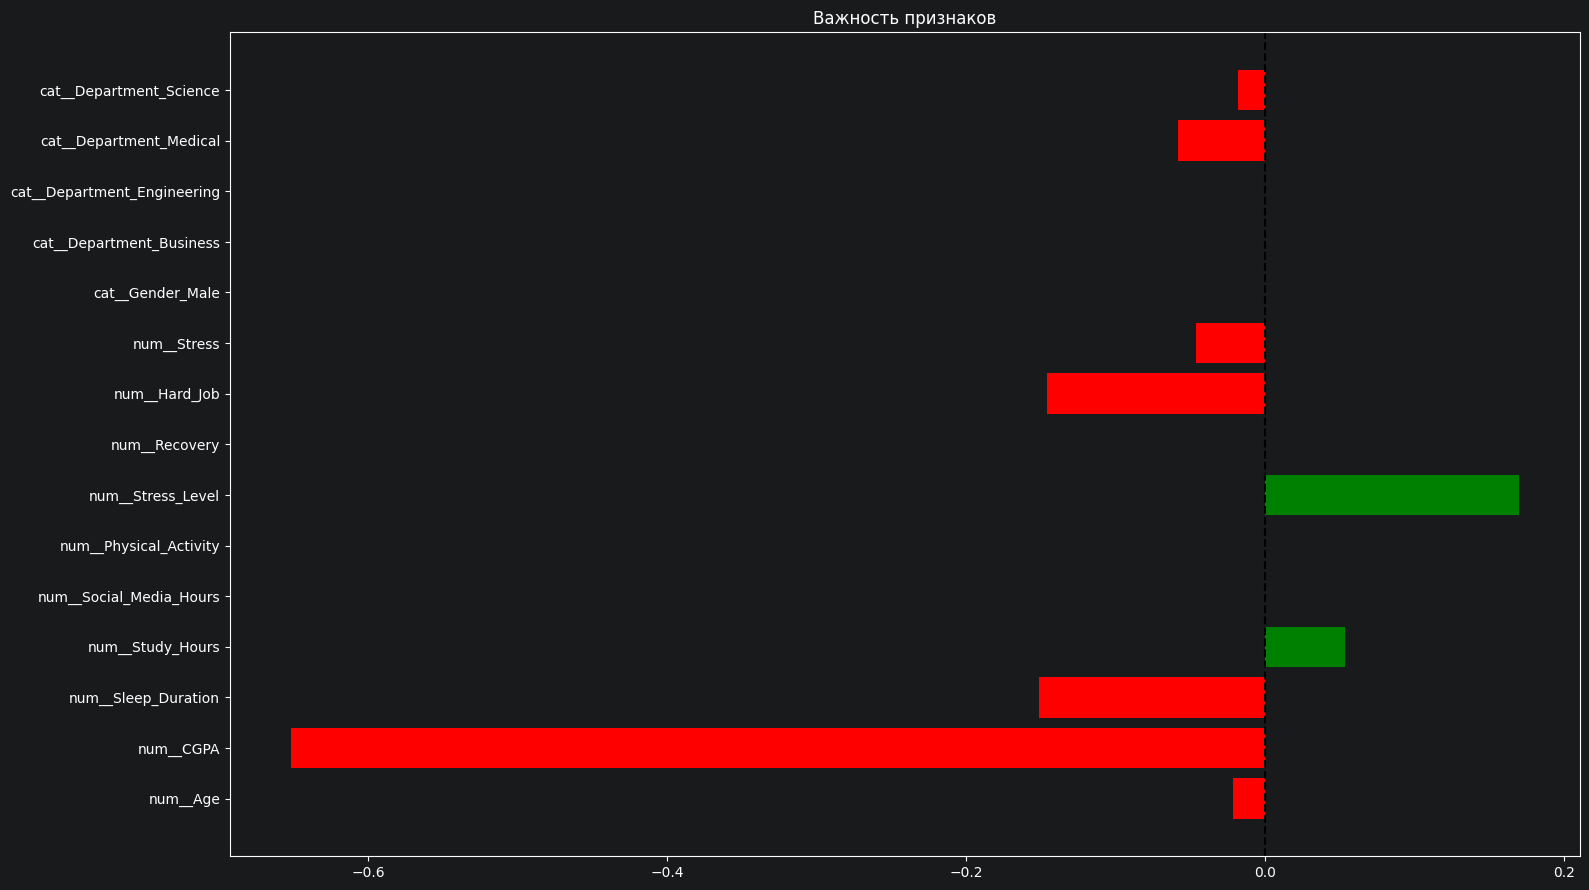

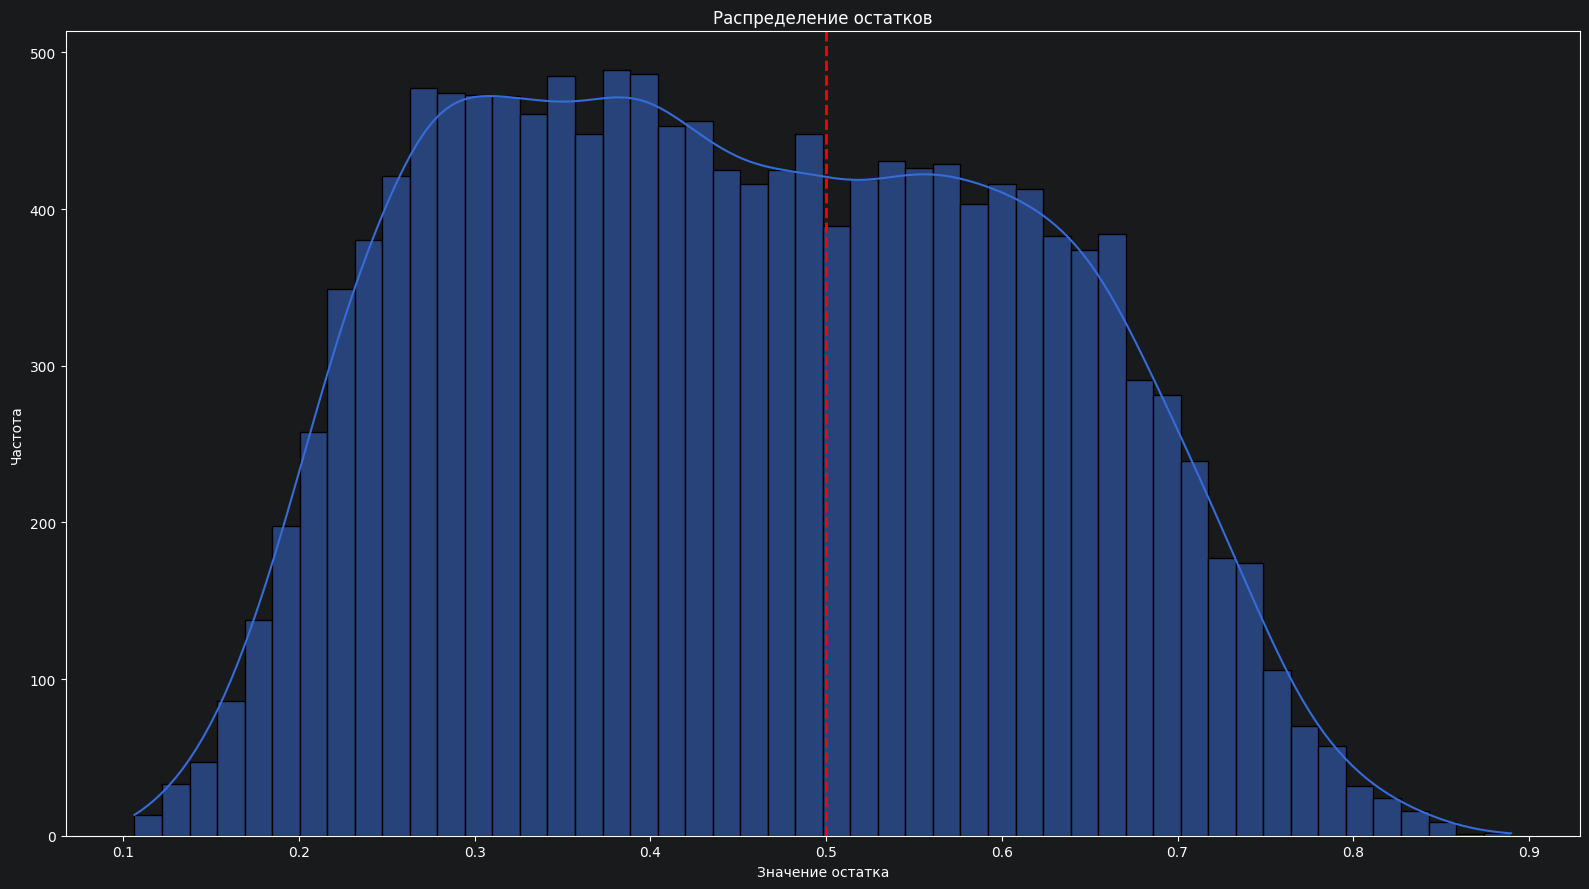

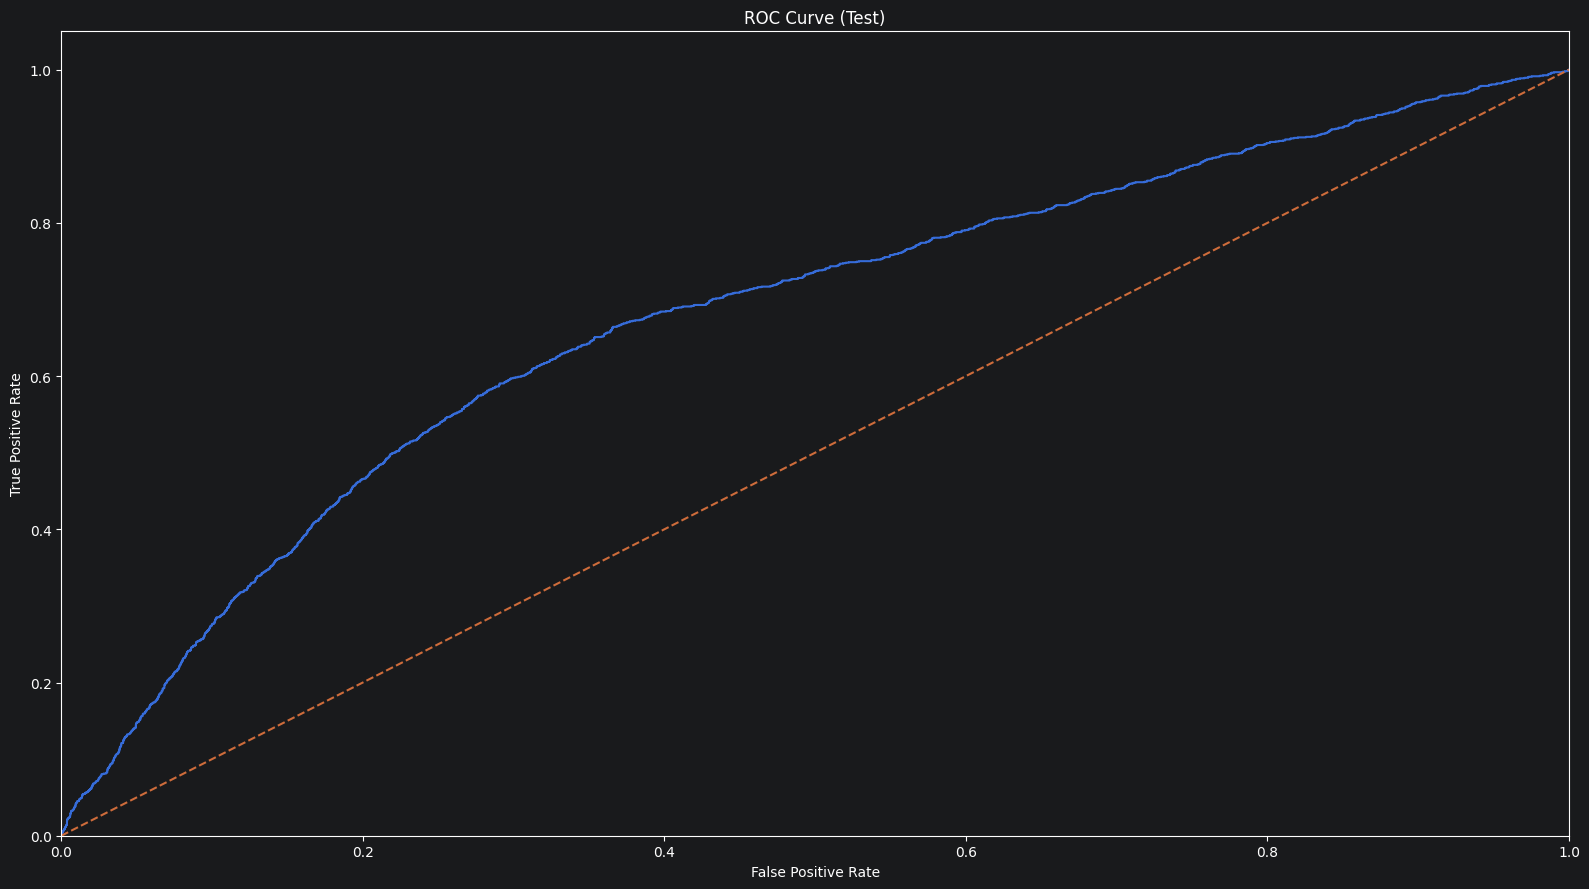

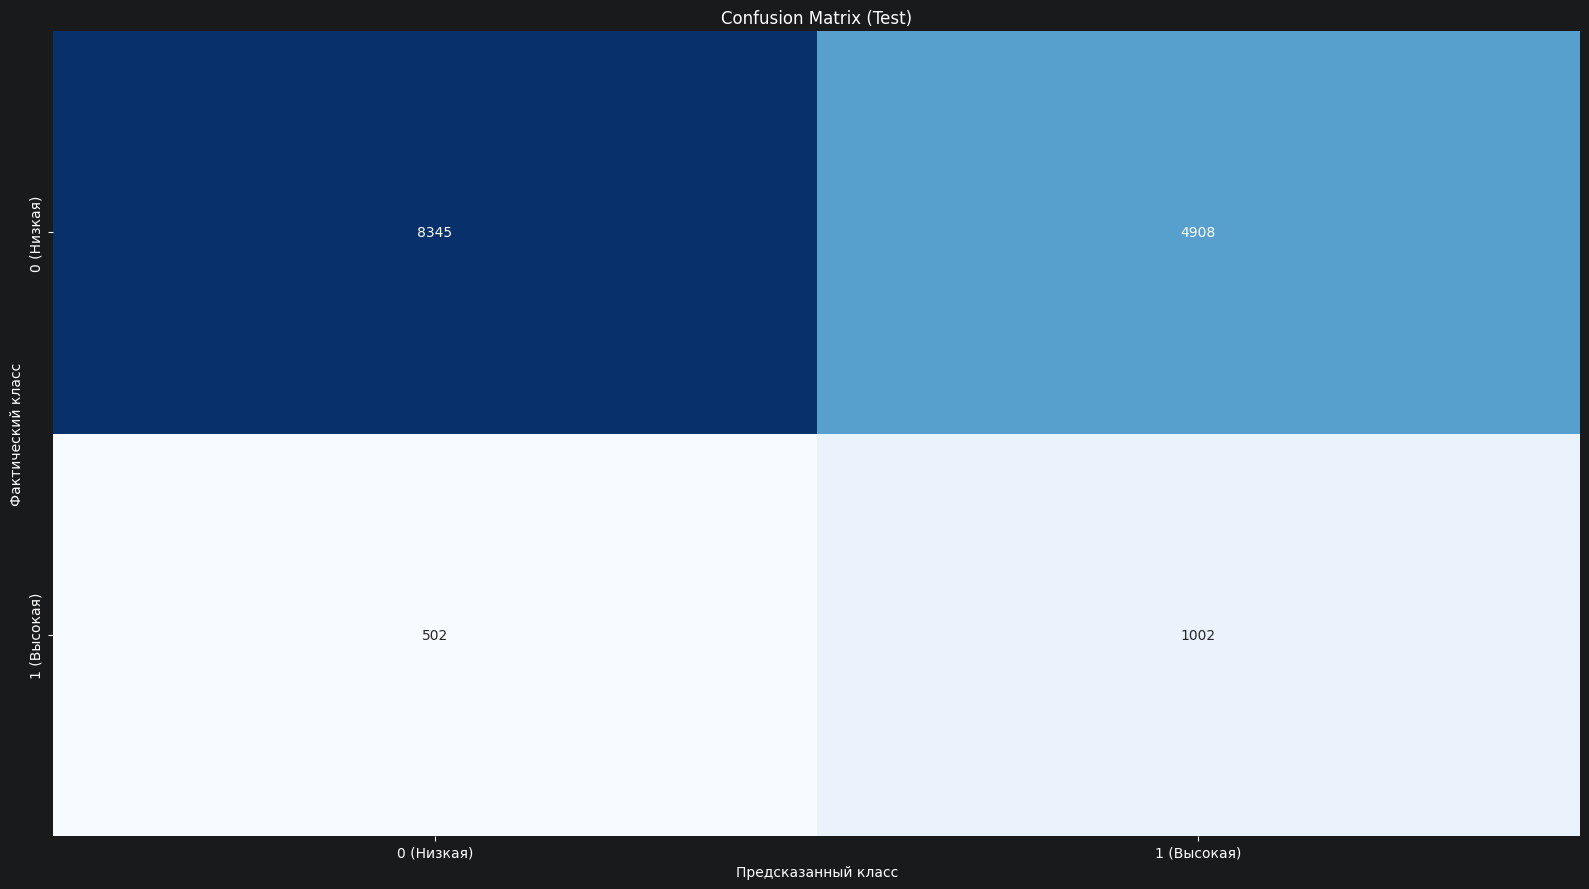

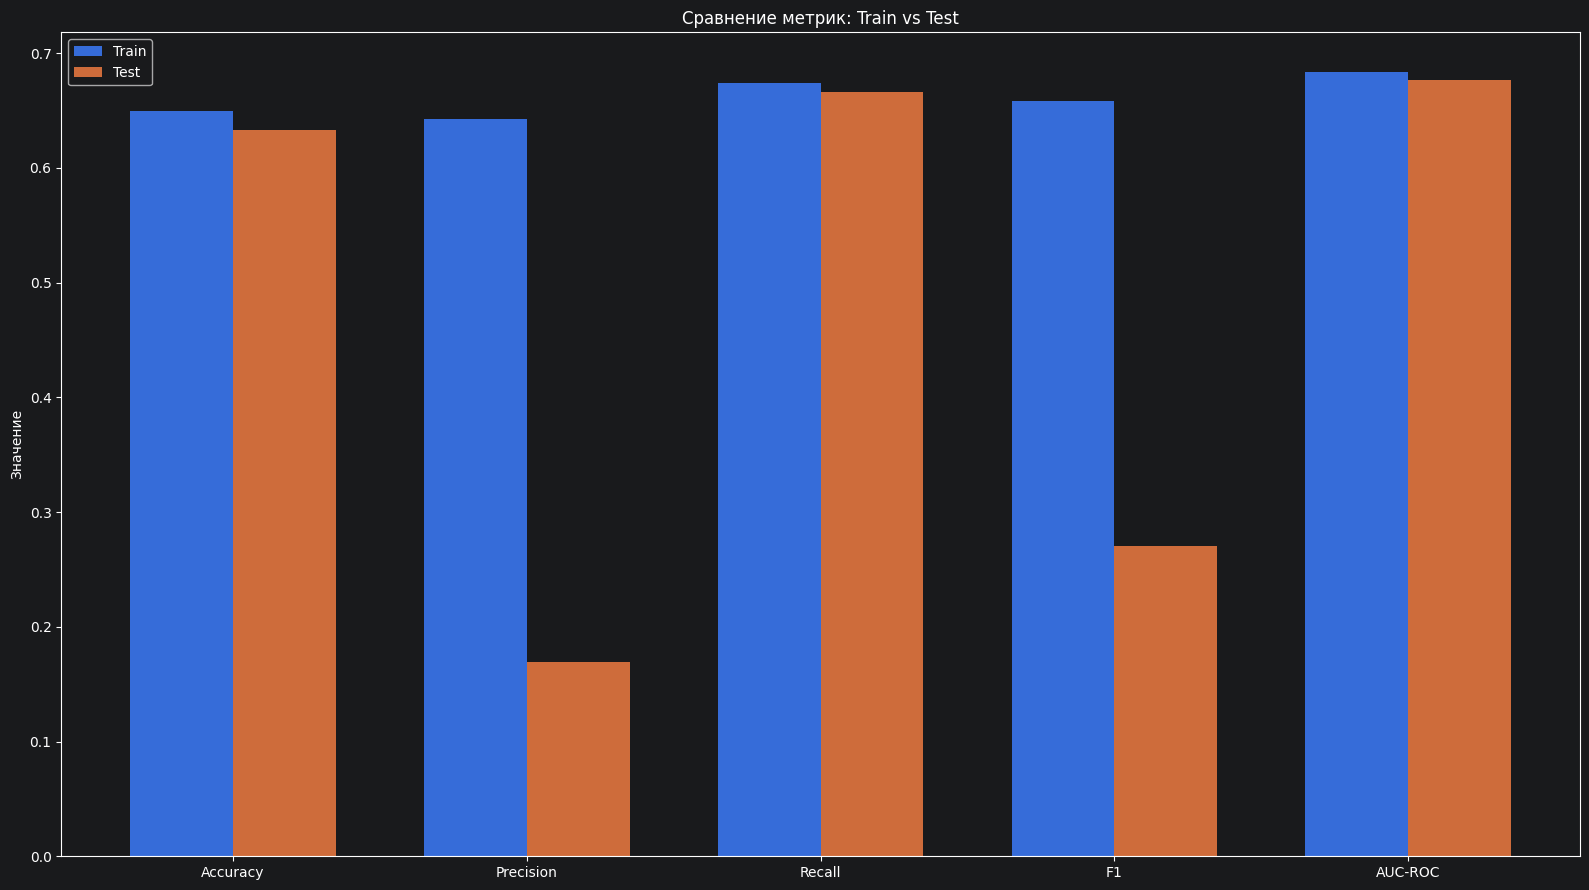

In [603]:
X_train, X_validate, X_test, y_train, y_validate, y_test, features = (
    split_dataset(dataset1, "Depression", need_resample=True))

results, model_1 = find_best(X_train, X_validate, y_train, y_validate, "classification")
model_1.fit(X_train, y_train)

y_train_predict = model_1.predict(X_train)
y_train_proba = model_1.predict_proba(X_train)[:, 1]

y_validate_predict = model_1.predict(X_validate)
y_validate_proba = model_1.predict_proba(X_validate)[:, 1]

y_test_predict = model_1.predict(X_test)
y_test_proba = model_1.predict_proba(X_test)[:, 1]

train_metrics = evaluate_classification(y_train, y_train_predict, y_train_proba, dataset_name="Train")
validate_metrics = evaluate_classification(y_validate, y_validate_predict, y_validate_proba, dataset_name="Validate")
test_metrics = evaluate_classification(y_test, y_test_predict, y_test_proba, dataset_name="Test")

create_coef_bar(model_1, features)
create_histplot_of_leftover(y_test_proba, np.zeros(len(y_test_proba)), center=0.5)
create_roc_curve(y_test, y_test_proba, test_metrics)
create_confusion_matrix(y_test, y_test_predict)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
create_comparison_of_metrics(train_metrics, test_metrics, metrics_names)


Обучим модель на втором датасете

Метрики для Train:
  Accuracy:  0.6531
  Precision: 0.6446
  Recall:    0.6824
  F1-Score:  0.6630
  AUC-ROC:   0.6875
Метрики для Validate:
  Accuracy:  0.6262
  Precision: 0.1620
  Recall:    0.6658
  F1-Score:  0.2606
  AUC-ROC:   0.6739
Метрики для Test:
  Accuracy:  0.6304
  Precision: 0.1700
  Recall:    0.6762
  F1-Score:  0.2716
  AUC-ROC:   0.6808


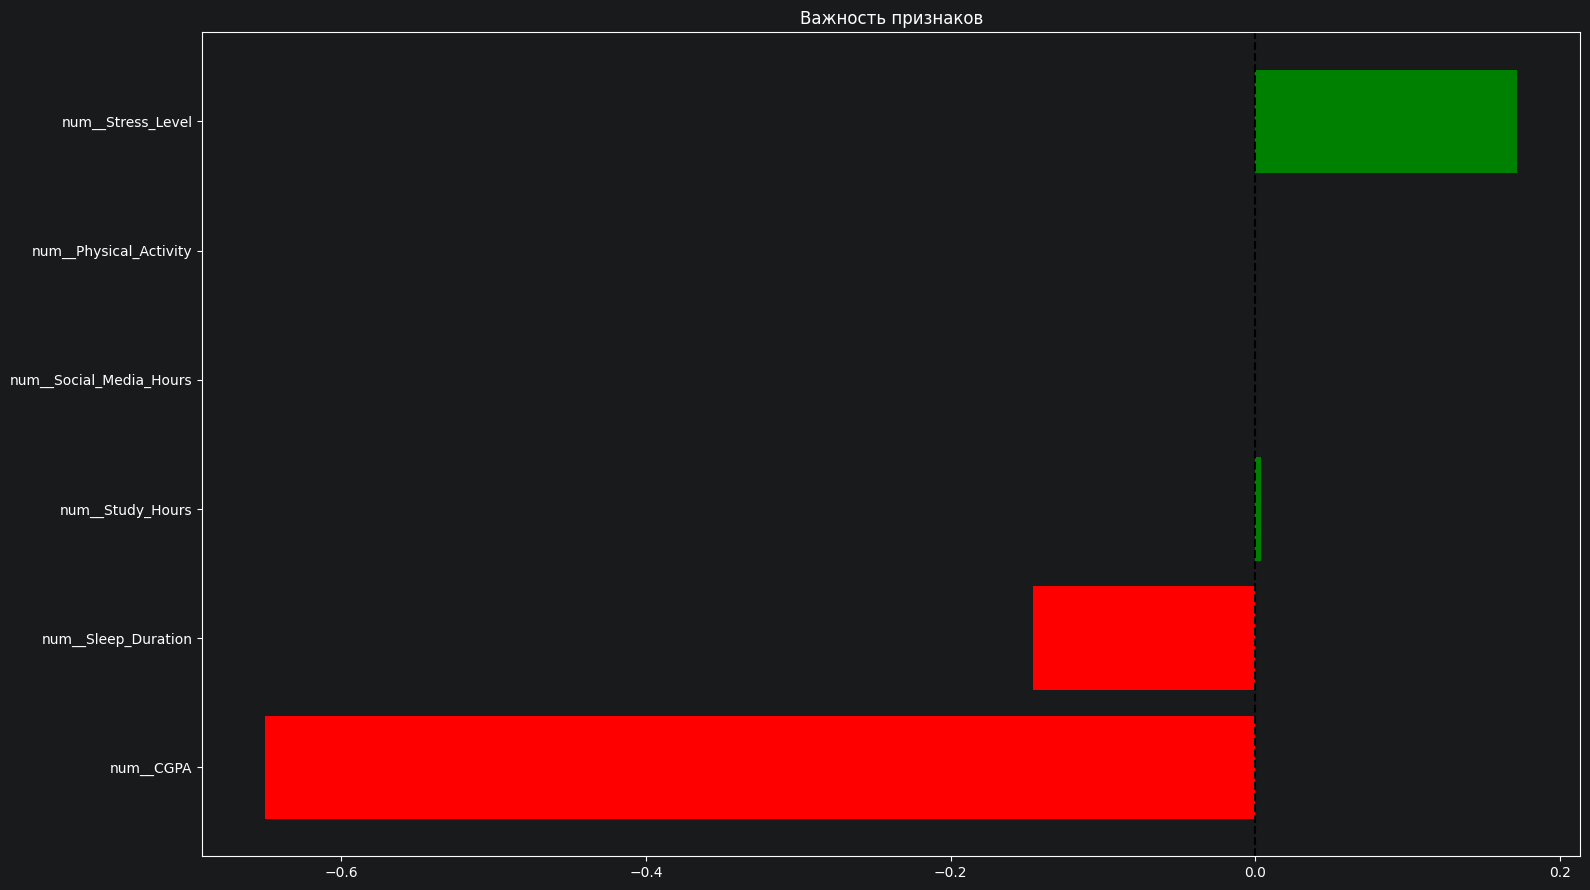

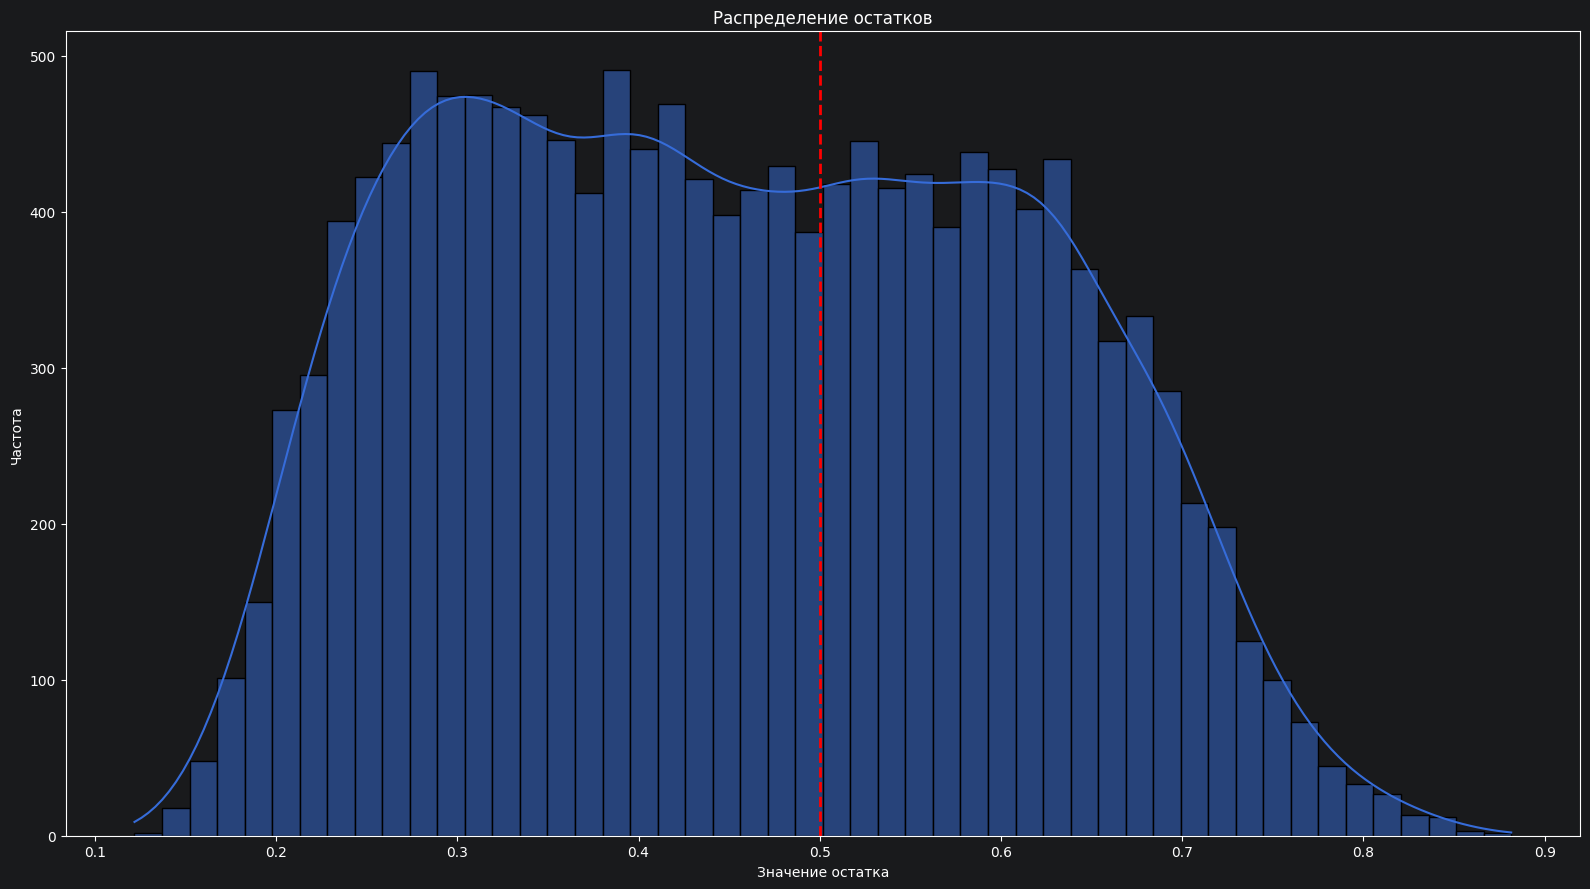

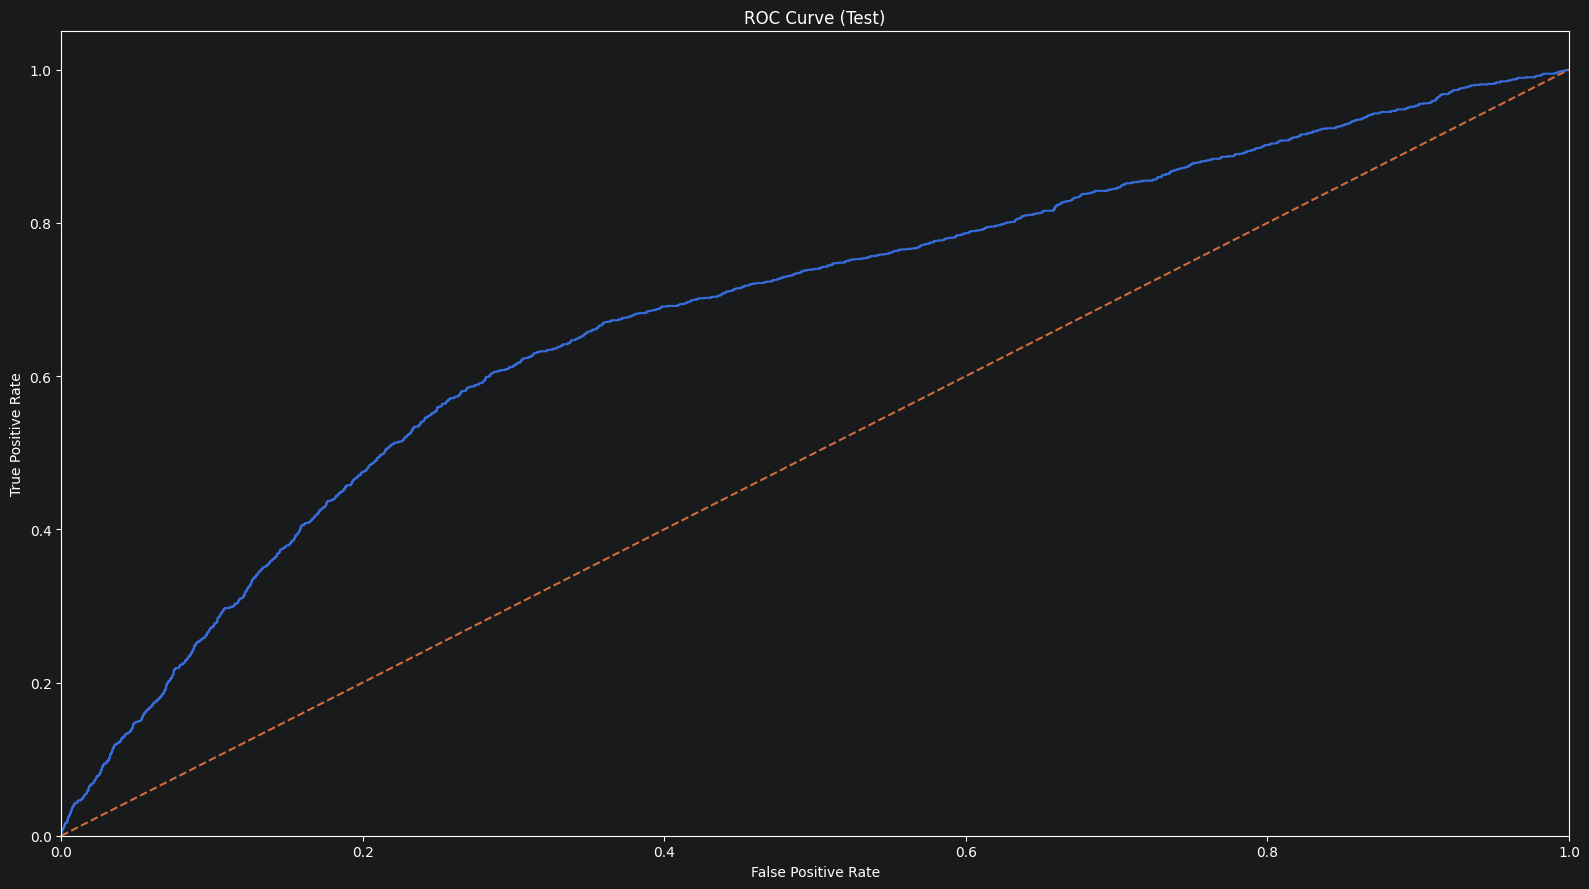

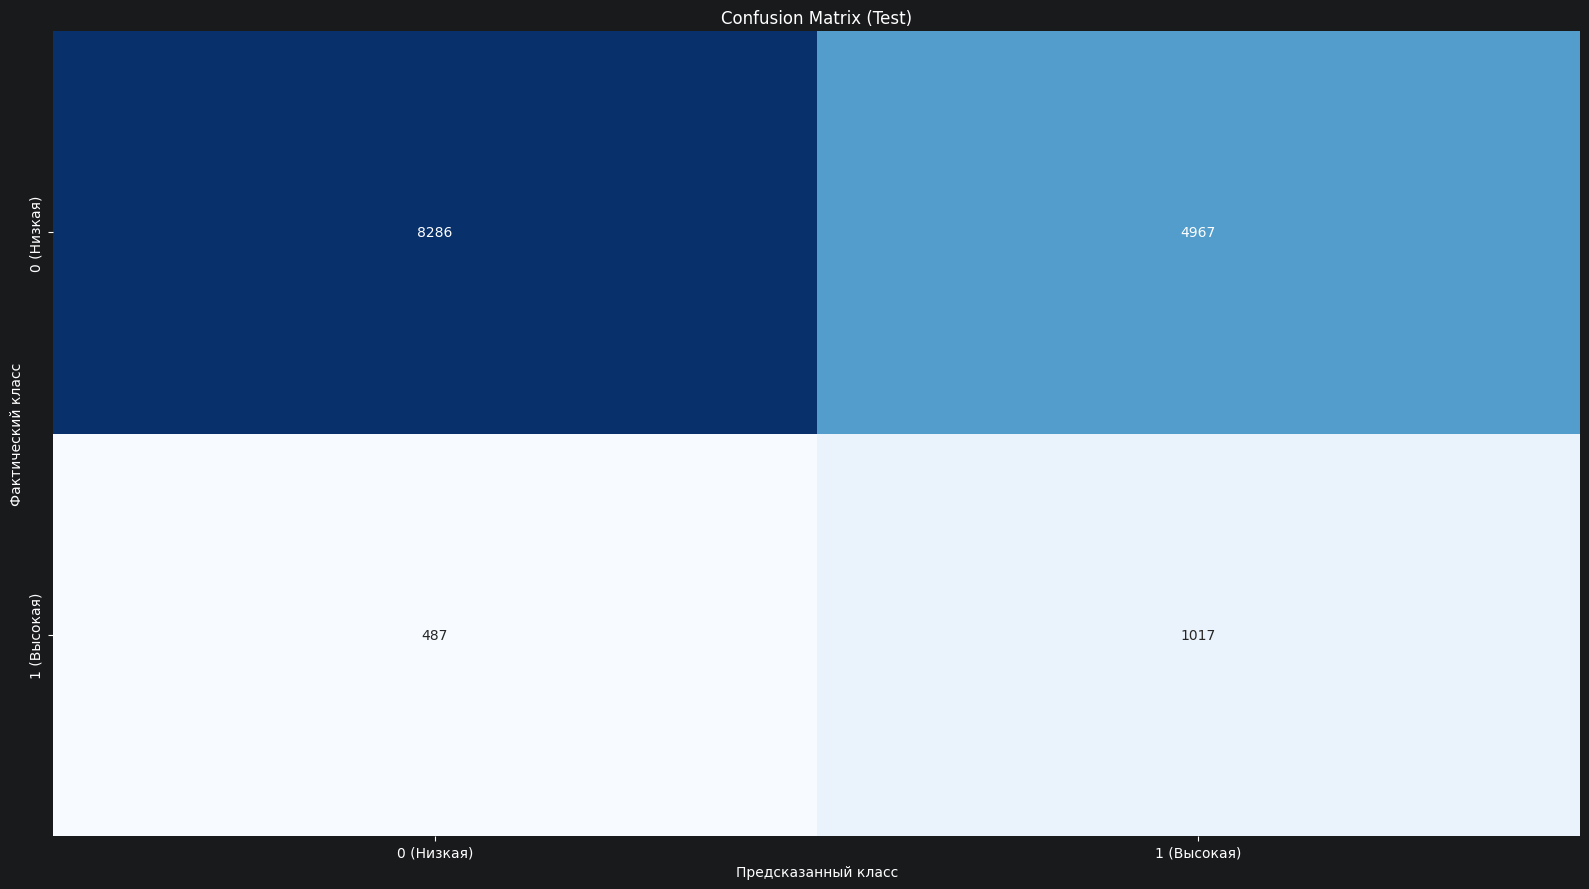

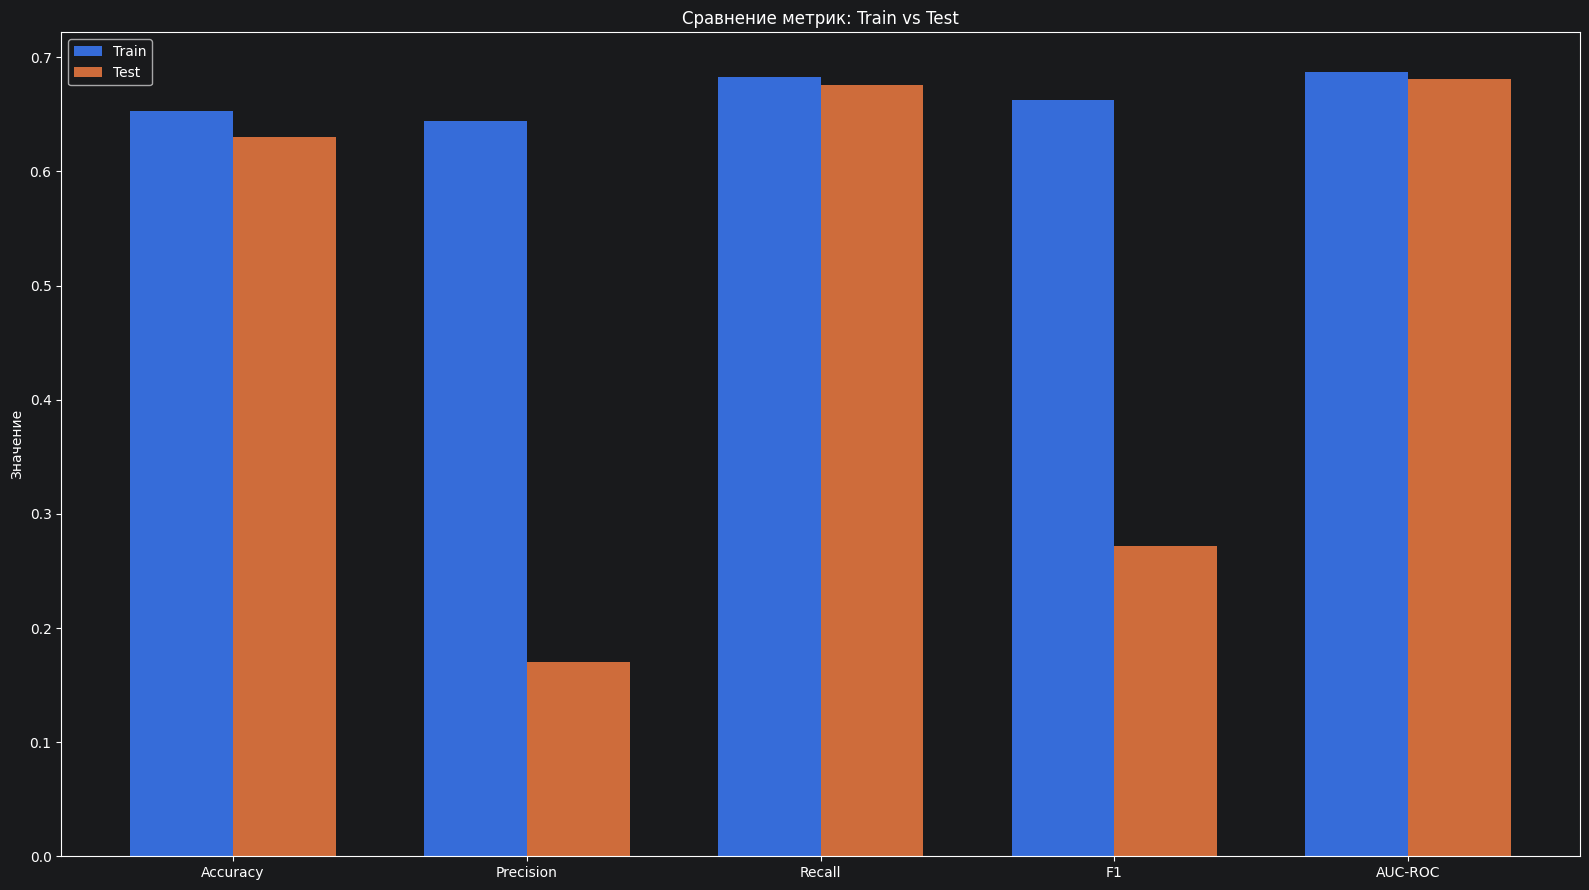

In [604]:
X_train, X_validate, X_test, y_train, y_validate, y_test, features = split_dataset(dataset2, "Depression",
                                                                                   need_resample=True)

n_epochs = 100
results, model_2 = find_best(X_train, X_validate, y_train, y_validate, "classification")
model_2.fit(X_train, y_train)

y_train_predict = model_2.predict(X_train)
y_train_proba = model_2.predict_proba(X_train)[:, 1]

y_validate_predict = model_2.predict(X_validate)
y_validate_proba = model_2.predict_proba(X_validate)[:, 1]

y_test_predict = model_2.predict(X_test)
y_test_proba = model_2.predict_proba(X_test)[:, 1]

train_metrics = evaluate_classification(y_train, y_train_predict, y_train_proba, dataset_name="Train")
validate_metrics = evaluate_classification(y_validate, y_validate_predict, y_validate_proba, dataset_name="Validate")
test_metrics = evaluate_classification(y_test, y_test_predict, y_test_proba, dataset_name="Test")

create_coef_bar(model_2, features)
create_histplot_of_leftover(y_test_proba, np.zeros(len(y_test_proba)), center=0.5)
create_roc_curve(y_test, y_test_proba, test_metrics)
create_confusion_matrix(y_test, y_test_predict)
create_comparison_of_metrics(train_metrics, test_metrics, metrics_names)


Preсision сильно отличается на тренировочной выборке от тестовой, из-за этого также отличается F1, это значит, что модель очень много выдает неправильных положительных ответов, то есть выделяет депрессию чаще чем она есть на самом деле. Из-за специфичности задачи, можно предположить, что лучше выявить депрессию и отправить человека на консультацию к специалисту, чем не выявить её, поэтому будем считать такую проблему в метриках допустимой. Модель не переобучена, так как имеет в полне адекватные остальные метрики в сравнении с тестовой и тренировочной выборкой

### Вывод
Модели получились не с самыми лучшими метриками. Также почти нет разницы в датасетах, датасет с обогащенными данными по метрикам, совсем немного лучше датасета с урезанными данными, из этого можно сделать вывод, что были выброшены очень малозначимые данные и таким образом можно чуток облегчить модель.

Очень важно для логистической модели оказалось уравнять количество людей с депрессией и без неё, так как иначе модель бы просто всегда предсказывала отсутствие депрессии и получала бы высокую точность. Также стоит заметить, что есть люди у которых в дне получается более 24 часов, их тоже стоит из датасета выбросить. В остальном датасет оказался чересчур идеальным и ровным. Также можно сказать, что люди с низкой оценкой чаще имеют депрессию, чем люди с высокой оценкой.

Поэтому можно поставить хорошую оценку, чтобы у меня не было депрессии :)